# Missing configurations recap + plotting + analysis

In [12]:
import re
import json
import sys
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root(start=Path.cwd()):
    """Locate this checkout regardless of the Jupyter launch directory."""
    for candidate in (start, *start.parents):
        if (candidate / "plots.ipynb").is_file() and (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not locate the entropy repository from the current directory")


REPO_ROOT = find_repo_root()
ROOT = REPO_ROOT / "data"
if not ROOT.is_dir():
    raise FileNotFoundError(
        f"Dataset not found at {ROOT}. Download it with: "
        "hf download saracandu/entropy-traces --type dataset --local-dir data"
    )

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

MODELS = [
    "Qwen3-4B", "Qwen3-14B",
    "gemma-4-E4B-it", "gemma-4-26B-A4B-it",
    "gpt-oss-20b", "gpt-oss-120b",
]

DATASETS = [
    "aime_2024", "aime2025", "aime_2026",
    "math-500", "gpqa", "zebralogic",
]

DATASET_LABELS = {
    "aime_2024": "AIME2024", "aime2025": "AIME2025", "aime_2026": "AIME2026",
    "math-500": "MATH-500", "gpqa": "GPQA-Diamond", "zebralogic": "ZebraLogic",
}

RATES = ["0.01", "0.05", "0.1", "0.2", "0.3", "0.4", "0.5", "0.6", "0.7", "0.8", "0.9", "1.0"]

# token-level selectors (results/)
TOKEN_SELECTORS = ["low_entropy", "high_entropy", "numbers", "random", "end_of_sentence", "newlines"]

# sentence-level selectors (results_sentence/) -- surface/nopatch only, no patched variant exists
SENTENCE_SELECTORS = ["low_entropy", "low_entropy_no_numbers", "numbers", "high_entropy", "random"]

SELECTOR_COLORS = {
    "random":                  "#999999",  # grigio neutro — baseline
    "low_entropy":              "#1A9CB0",  # teal — criterio principale
    "numbers":                  "#1B7837",  # verde scuro — sottoinsieme "numerico" di low_entropy
    "low_entropy_no_numbers":   "#66C2A5",  # teal chiaro — sottoinsieme "depurato" di low_entropy
    "high_entropy":             "#D95F02",  # arancione — polo opposto sull'asse entropia
    "newlines":                 "#E6AB02",  # ambra/senape — pattern strutturale
    "end_of_sentence":          "#B15928",  # terracotta — stesso tipo, tonalità affine a newlines
}

N_BOOTSTRAP = 1000

# --- FILENAME PATTERNS ---
# Token-level: patch and surface (nopatch) live INSIDE THE SAME FILE, not separate files.
#   {model}_teacher_traces_eval_{selector}_r{rate}.json
# Sentence-level, SURFACE (nopatch), the only variant that exists:
#   {model}_teacher_traces_eval_sentence_{selector}_r{rate}_nopatch.json

TOKEN_TMPL    = "{model}_teacher_traces_eval_{selector}_r{rate}.json"
SENTENCE_TMPL = "{model}_teacher_traces_eval_sentence_{selector}_r{rate}_nopatch.json"


## 1. Sanity check on a sample dataset/model

In [13]:
sample_dataset = "aime2025"
sample_model = "Qwen3-14B"

results_dir = ROOT / sample_dataset / "results"
if results_dir.exists():
    files = sorted(results_dir.glob(f"{sample_model}_teacher_traces_eval_*.json"))[:5]
    for f in files:
        data = json.load(open(f))
        print(f.name, "-> skip_patched =", data.get("skip_patched"), "| selector =", data.get("selector"), "| rate =", data.get("retention_rate"))
else:
    print(f"{results_dir} does not exist.")


Qwen3-14B_teacher_traces_eval_end_of_sentence_r0.01.json -> skip_patched = False | selector = end_of_sentence | rate = 0.01
Qwen3-14B_teacher_traces_eval_end_of_sentence_r0.05.json -> skip_patched = False | selector = end_of_sentence | rate = 0.05
Qwen3-14B_teacher_traces_eval_end_of_sentence_r0.1.json -> skip_patched = False | selector = end_of_sentence | rate = 0.1
Qwen3-14B_teacher_traces_eval_end_of_sentence_r0.2.json -> skip_patched = False | selector = end_of_sentence | rate = 0.2
Qwen3-14B_teacher_traces_eval_end_of_sentence_r0.3.json -> skip_patched = False | selector = end_of_sentence | rate = 0.3


## 2. Inventory scan -- builds a DataFrame with everything that is present

In [14]:
def build_inventory():
    rows = []
    for dataset in DATASETS:
        ds_dir = ROOT / dataset
        for model in MODELS:
            trace_f = ds_dir / f"{model}_teacher_traces.json"
            trace_present = trace_f.exists()
            rows.append({
                "dataset": dataset, "model": model, "level": "trace",
                "selector": None, "rate": None, "patch": None,
                "present": trace_present,
            })
            if not trace_present:
                continue

            # --- token-level: check the files actually present ---
            # Every file always contains the surface variant (reached_only/random_only).
            # The patched variant (reached_patched/random_patched) is only present if skip_patched == False.
            results_dir = ds_dir / "results"
            if results_dir.exists():
                for f in results_dir.glob(f"{model}_teacher_traces_eval_*.json"):
                    try:
                        data = json.load(open(f))
                        skip_patched = data.get("skip_patched")
                        selector = data.get("selector")
                        rate = str(data.get("retention_rate"))
                    except Exception as e:
                        print(f"!! error reading {f}: {e}")
                        continue
                    # surface: always present if the file exists
                    rows.append({
                        "dataset": dataset, "model": model, "level": "token",
                        "selector": selector, "rate": rate, "patch": False,
                        "present": True,
                    })
                    # patched: present only if skip_patched == False
                    rows.append({
                        "dataset": dataset, "model": model, "level": "token",
                        "selector": selector, "rate": rate, "patch": True,
                        "present": (skip_patched is False),
                    })

            # --- sentence-level: only files that exist (surface only, as noted above) ---
            results_sent_dir = ds_dir / "results_sentence"
            if results_sent_dir.exists():
                for f in results_sent_dir.glob(f"{model}_teacher_traces_eval_sentence_*_nopatch.json"):
                    m = re.search(r"eval_sentence_(.+)_r([\d.]+)_nopatch\.json$", f.name)
                    if not m:
                        continue
                    rows.append({
                        "dataset": dataset, "model": model, "level": "sentence",
                        "selector": m.group(1), "rate": m.group(2), "patch": False,
                        "present": True,
                    })

    return pd.DataFrame(rows)

inventory = build_inventory()
inventory.shape


(8196, 7)

## 3. Missing-configuration recap -- granular, filter as needed

In [15]:
have_trace = set(
    (r.dataset, r.model) for r in inventory[(inventory["level"] == "trace") & (inventory["present"])].itertuples()
)

expected_token = pd.DataFrame(
    [(d, m, sel, rate, patch) for d, m in have_trace for sel in TOKEN_SELECTORS for rate in RATES for patch in [False, True]],
    columns=["dataset", "model", "selector", "rate", "patch"]
)
present_token = inventory[inventory["level"] == "token"][["dataset", "model", "selector", "rate", "patch", "present"]]
missing_token = expected_token.merge(present_token, how="left", on=["dataset", "model", "selector", "rate", "patch"])
missing_token = missing_token[(missing_token["present"].isna()) | (missing_token["present"] == False)].drop(columns="present")

expected_sentence = pd.DataFrame(
    [(d, m, sel, rate) for d, m in have_trace for sel in SENTENCE_SELECTORS for rate in RATES],
    columns=["dataset", "model", "selector", "rate"]
)
present_sentence = inventory[inventory["level"] == "sentence"][["dataset", "model", "selector", "rate"]]
missing_sentence = expected_sentence.merge(present_sentence.assign(_p=True), how="left", on=["dataset", "model", "selector", "rate"])
missing_sentence = missing_sentence[missing_sentence["_p"].isna()].drop(columns="_p")

missing_all = pd.concat([
    missing_token.assign(level="token"),
    missing_sentence.assign(level="sentence", patch=False),
], ignore_index=True)[["level", "dataset", "model", "selector", "patch", "rate"]]
missing_all = missing_all.sort_values(["level", "dataset", "model", "selector", "patch"]).reset_index(drop=True)
missing_all


,level,dataset,model,selector,patch,rate


## 4. Curve loading, bootstrap CI, and single-panel plotting

In [16]:
def load_token_json(dataset, model, selector, rate):
    f = ROOT / dataset / "results" / f"{model}_teacher_traces_eval_{selector}_r{rate}.json"
    if not f.exists():
        return None
    return json.load(open(f))


def load_sentence_json(dataset, model, selector, rate):
    f = ROOT / dataset / "results_sentence" / f"{model}_teacher_traces_eval_sentence_{selector}_r{rate}_nopatch.json"
    if not f.exists():
        return None
    return json.load(open(f))


def per_trace_correctness(data, patch=False):
    """Returns two parallel arrays (correct_selector, correct_full), one element per trace."""
    key = "reached_patched" if patch else "reached_only"
    sel, full = [], []
    for item in data["results"]:
        tr = item["trace"]
        if key not in tr or "full_sequence" not in tr:
            continue
        sel.append(int(tr[key]["correct"]))
        full.append(int(tr["full_sequence"]["correct"]))
    return np.array(sel), np.array(full)


def bootstrap_relative_pr(correct_sel, correct_full, n_bootstrap=N_BOOTSTRAP, seed=0):
    """Relative PR = accuracy_selector / accuracy_full, with bootstrap CI over traces."""
    n = len(correct_sel)
    if n == 0 or correct_full.sum() == 0:
        return None, None, None
    rng = np.random.default_rng(seed)
    point = correct_sel.sum() / correct_full.sum()
    boots = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        f = correct_full[idx].sum()
        if f == 0:
            continue
        boots.append(correct_sel[idx].sum() / f)
    if not boots:
        return point, point, point
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return point, lo, hi


def get_curve_with_ci(dataset, model, selector, level="token", patch=False):
    loader = load_token_json if level == "token" else load_sentence_json
    xs, ys, los, his = [], [], [], []
    for rate in RATES:
        data = loader(dataset, model, selector, rate)
        if data is None:
            continue
        sel, full = per_trace_correctness(data, patch=(patch if level == "token" else False))
        point, lo, hi = bootstrap_relative_pr(sel, full)
        if point is None:
            continue

        # EFFECTIVE compression rate: average over all traces of n_tokens_reached/n_tokens_thinking
        actual_retentions = []
        for item in data["results"]:
            tr = item["trace"]
            nr = tr.get("n_tokens_reached")
            nt = tr.get("n_tokens_thinking")
            if nr is not None and nt:
                actual_retentions.append(nr / nt)
        actual_retention = np.mean(actual_retentions) if actual_retentions else float(rate)

        xs.append(actual_retention); ys.append(point); los.append(lo); his.append(hi)

    xs = np.array(xs)
    order = np.argsort(xs)
    return xs[order], np.array(ys)[order], np.array(los)[order], np.array(his)[order]


def plot_curves(dataset, model, selectors, level="token", patch=False, x_axis="compression",
                 title=None, ax=None, save=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(6, 4))
    for sel in selectors:
        xs, ys, los, his = get_curve_with_ci(dataset, model, sel, level=level, patch=patch)
        if len(xs) == 0:
            continue
        if x_axis == "compression":
            xs = 1 - xs
        color = SELECTOR_COLORS.get(sel, None)
        ax.plot(xs, ys, marker="o", label=sel, color=color)
        ax.fill_between(xs, los, his, color=color, alpha=0.15, linewidth=0)
    ax.set_xlabel("compression rate" if x_axis == "compression" else "retention rate")
    ax.set_ylabel("relative performance retention")
    suffix = ", patch" if patch else ""
    ax.set_title(title or f"{model} / {dataset} ({level}{suffix})")
    ax.legend()
    ax.grid(alpha=0.3)
    if standalone:
        if save:
            Path(save).parent.mkdir(parents=True, exist_ok=True)
            plt.savefig(save, dpi=600, bbox_inches="tight")
        plt.show()


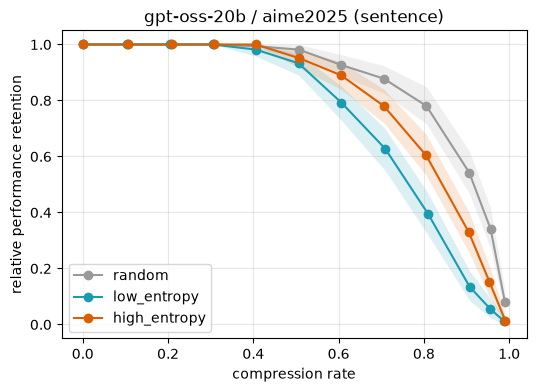

In [17]:
plot_curves(
    dataset="aime2025",
    model="gpt-oss-20b",
    selectors=["random", "low_entropy", "high_entropy"],
    level="sentence",
    patch=False,
    # save="figures/gptoss20b_aime2025_sentence.pdf",
)


## 5. Multi-panel plotting: dataset strip and full model x dataset grid

In [18]:
def plot_dataset_strip(model, datasets, selectors=["random", "low_entropy", "high_entropy"],
                        level="sentence", patch=False, ncols=None, save=None):
    ncols = ncols or len(datasets)
    nrows = int(np.ceil(len(datasets) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.2 * nrows), sharey=True)
    axes = np.atleast_1d(axes).flatten()

    for ax, dataset in zip(axes, datasets):
        plot_curves(
            dataset=dataset, model=model, selectors=selectors,
            level=level, patch=patch, ax=ax,
            title=dataset,
        )
        ax.get_legend().remove()
        ax.set_ylabel("")

    for ax in axes[len(datasets):]:
        ax.axis("off")

    fig.text(0.0, 0.5, "relative performance retention", va="center", rotation="vertical")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(selectors),
               bbox_to_anchor=(0.5, 1.06))
    fig.suptitle(f"{model} ({level}{', patch' if patch else ''})", y=1.14)
    fig.tight_layout()

    if save:
        Path(save).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save, dpi=600, bbox_inches="tight")
    plt.show()


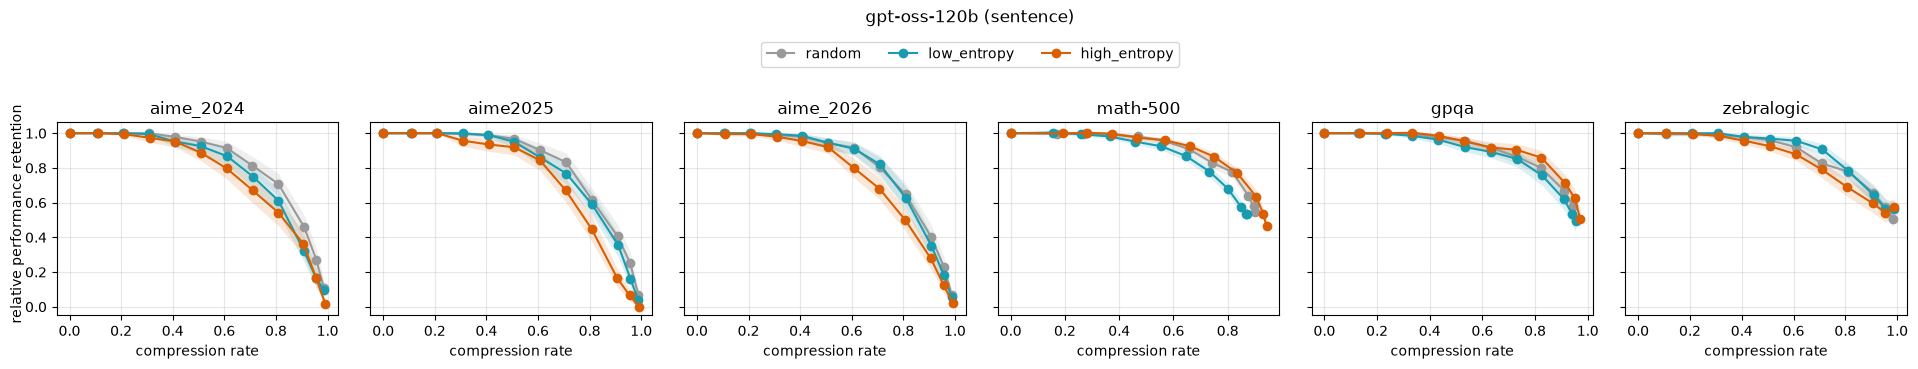

In [19]:
plot_dataset_strip(
    model="gpt-oss-120b",
    datasets=DATASETS,
    level="sentence",
    # save="figures/appendix_strip_gptoss20b_sentence.pdf",
)

In [20]:
def plot_full_grid(models, datasets, selectors=["random", "low_entropy", "high_entropy"],
                    level="sentence", patch=False, save=None):
    nrows, ncols = len(models), len(datasets)
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.2 * ncols, 3.2 * nrows), sharex=True, sharey=True)
    axes = np.asarray(axes).reshape(nrows, ncols)

    for i, model in enumerate(models):
        for j, dataset in enumerate(datasets):
            ax = axes[i, j]
            plot_curves(
                dataset=dataset, model=model, selectors=selectors,
                level=level, patch=patch, ax=ax,
            )
            ax.set_title("")
            ax.get_legend().remove()
            ax.set_ylabel("")
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelsize=10)
            if i == 0:
                ax.set_title(DATASET_LABELS.get(dataset, dataset))
            if j == 0:
                ax.set_ylabel(model, fontsize=10)

    fig.tight_layout(rect=[0.02, 0.02, 1, 0.97])

    # etichette più vicine ai plot e più grandi
    fig.text(0.005, 0.5, "relative performance retention",
              va="center", rotation="vertical", fontsize=13)
    fig.text(0.5, 0.005, "compression rate",
              ha="center", fontsize=13)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(selectors),
               bbox_to_anchor=(0.5, 1.0), frameon=False, fontsize=11)

    if save:
        Path(save).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save, dpi=600, bbox_inches="tight")
    plt.show()

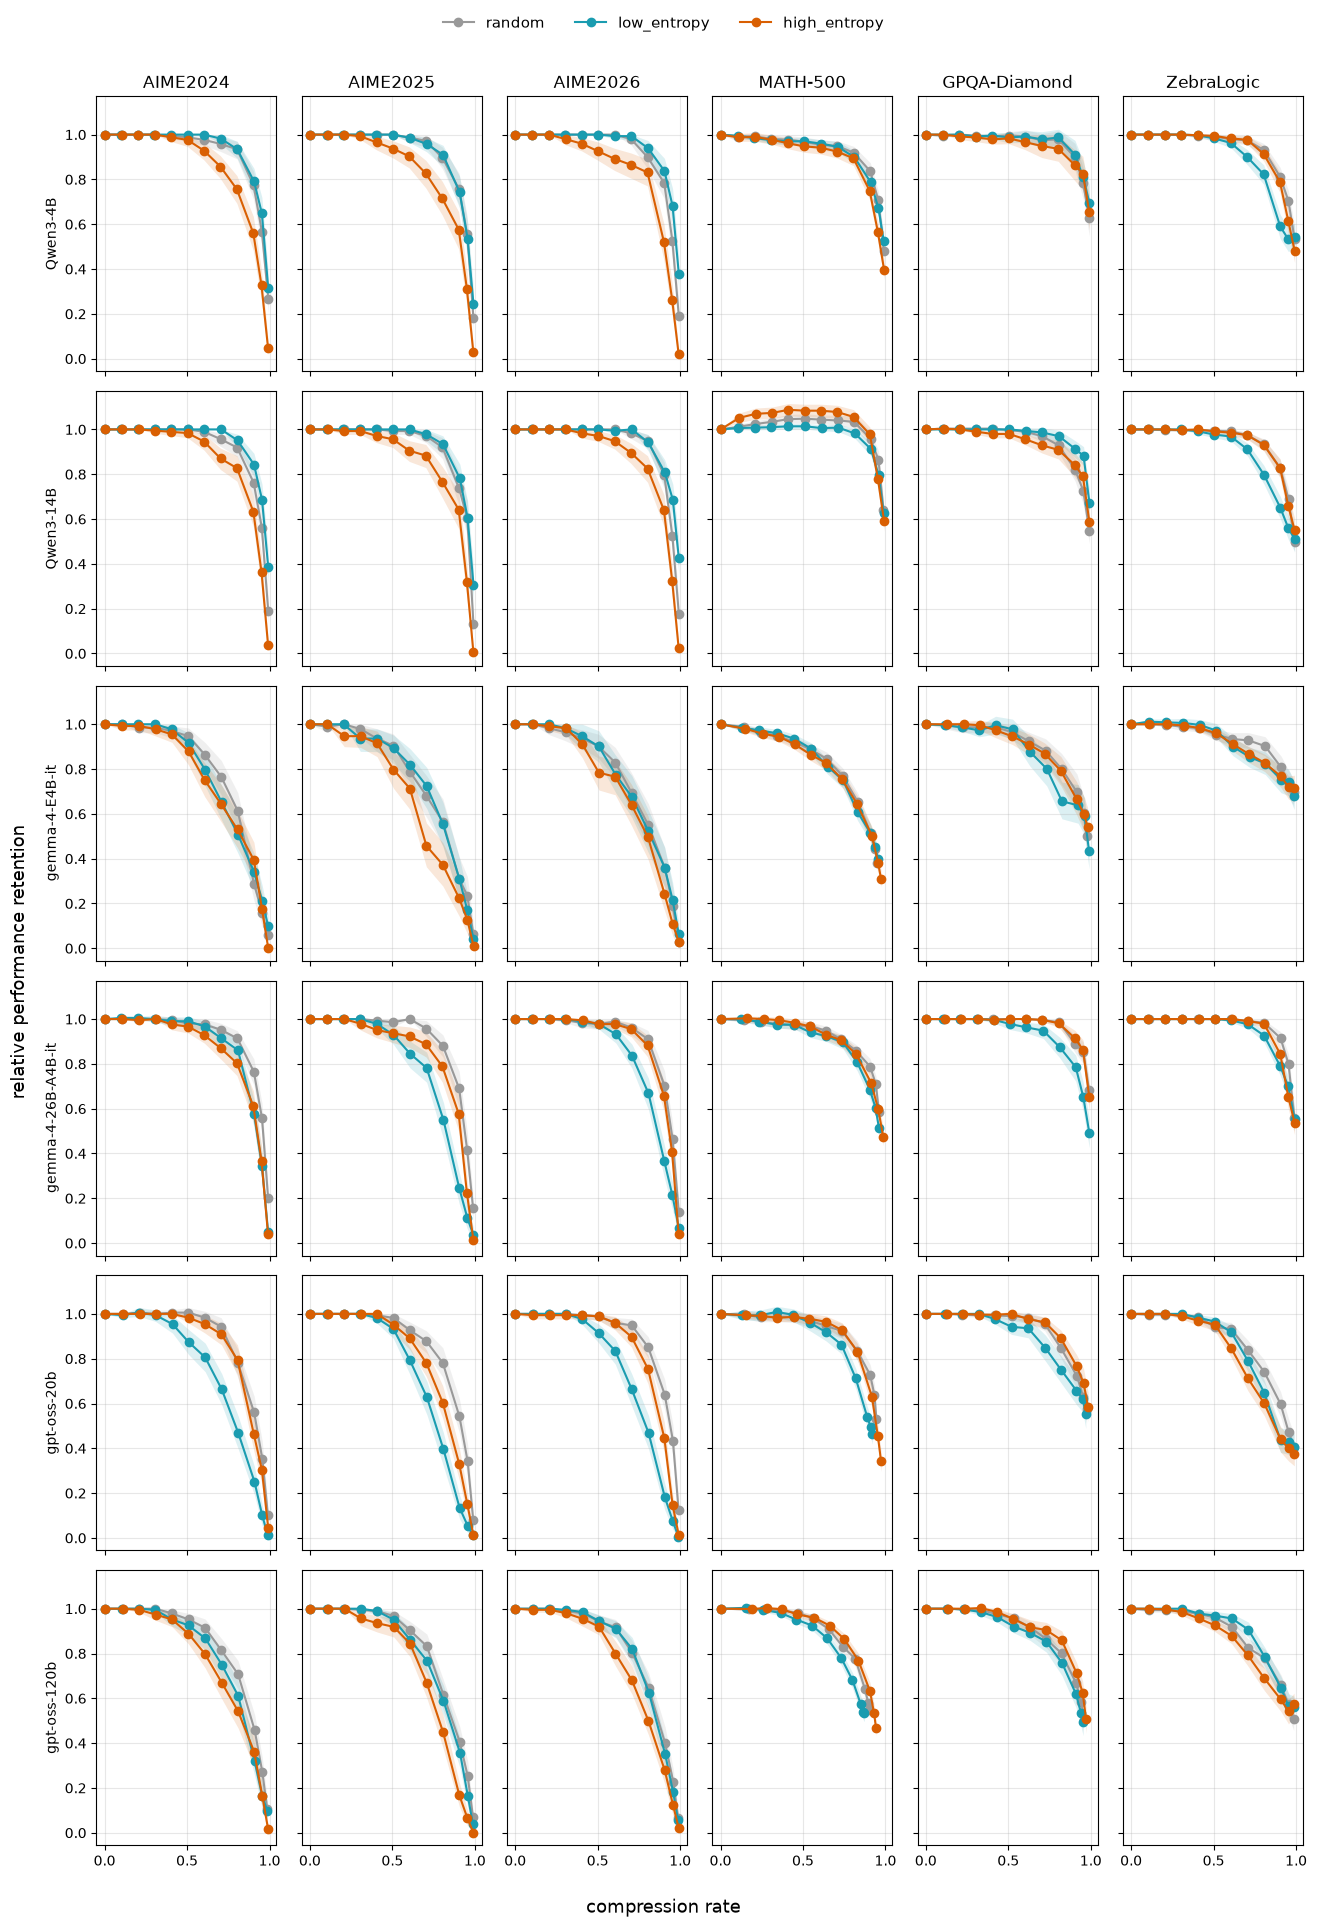

In [21]:
plot_full_grid(
    models=MODELS,
    datasets=DATASETS,
    level="sentence",
    save="figures/appendix_full_grid_sentence_no_numbers.pdf",
)

## 6. AUC / delta-AUC table (sentence-level)

In [22]:
def find_sentence_files(data_dir: Path):
    files = []
    for dataset in DATASETS:
        d = data_dir / dataset / "results_sentence"
        if not d.exists():
            continue
        for f in d.glob("*_eval_sentence_*_nopatch.json"):
            files.append((dataset, f))
    return files


def load_raw_sentence_records(data_dir: Path):
    """One row = one trace: (model, dataset, selector, rate, trace_id) ->
    reached_correct, full_correct. trace_id = (question_id, trace_index)."""
    files = find_sentence_files(data_dir)
    rows = []
    for dataset, fpath in files:
        try:
            d = json.load(open(fpath))
        except Exception as e:
            print(f"SKIP {fpath}: {e}")
            continue
        model = d.get("model", "?").split("/")[-1]
        selector = d.get("selector", "?")
        rate = d.get("retention_rate", None)
        results = d.get("results", [])
        if rate is None or not results:
            continue
        for r in results:
            trace = r.get("trace", {})
            rc = trace.get("reached_only", {}).get("correct")
            fc = trace.get("full_sequence", {}).get("correct")
            if rc is None or fc is None:
                continue
            rows.append({
                "model": model, "dataset": dataset, "selector": selector,
                "rate": rate,
                "trace_id": (r.get("question_id"), trace.get("trace_index")),
                "reached_correct": int(bool(rc)), "full_correct": int(bool(fc)),
            })
    return pd.DataFrame(rows)


raw_sentence = load_raw_sentence_records(ROOT)


def _prep_selector(sub, trace_ids):
    """Precomputes numpy arrays for a single model/dataset/selector combo,
    ready to be aggregated quickly at every bootstrap resample."""
    tid_to_idx = {t: i for i, t in enumerate(trace_ids)}
    rates = np.sort(sub["rate"].unique())
    rate_to_col = {r: i for i, r in enumerate(rates)}
    t_idx = sub["trace_id"].map(tid_to_idx).to_numpy()
    r_idx = sub["rate"].map(rate_to_col).to_numpy()
    reached = sub["reached_correct"].to_numpy(dtype=float)
    full = sub["full_correct"].to_numpy(dtype=float)
    return t_idx, r_idx, reached, full, rates


def _auc_from_counts(counts, t_idx, r_idx, reached, full, rates):
    """counts: array (n_trace_ids,) with the number of times each trace_id
    was resampled in the current draw (all-ones counts = original data)."""
    w = counts[t_idx]
    n_rates = len(rates)
    reached_w = np.bincount(r_idx, weights=reached * w, minlength=n_rates)
    full_w = np.bincount(r_idx, weights=full * w, minlength=n_rates)
    w_sum = np.bincount(r_idx, weights=w, minlength=n_rates)

    valid = w_sum > 0
    safe_w = np.where(valid, w_sum, 1.0)
    rel_pr = reached_w / safe_w
    full_mean = full_w / safe_w
    valid = valid & (full_mean > 0)

    if valid.sum() == 0:
        return np.nan
    return np.trapezoid(rel_pr[valid], rates[valid])


def bootstrap_delta_auc(raw, model, dataset, selector_a, selector_b="random",
                         patched=None, n_boot=1000, seed=0):
    """Trace-level bootstrap CI, same resample reused across all rates and
    both selectors (preserves correlation). Vectorized numpy version: no
    DataFrame operations inside the bootstrap loop."""
    base = raw[(raw.model == model) & (raw.dataset == dataset)]
    if patched is not None:
        base = base[base.patched == patched]
    sub_a = base[base.selector == selector_a]
    sub_b = base[base.selector == selector_b]
    if sub_a.empty or sub_b.empty:
        return None

    trace_ids = sorted(base.trace_id.unique(), key=str)
    n = len(trace_ids)
    if n == 0:
        return None

    ta_idx, ra_idx, reached_a, full_a, rates_a = _prep_selector(sub_a, trace_ids)
    tb_idx, rb_idx, reached_b, full_b, rates_b = _prep_selector(sub_b, trace_ids)

    ones = np.ones(n)
    point = (_auc_from_counts(ones, ta_idx, ra_idx, reached_a, full_a, rates_a)
              - _auc_from_counts(ones, tb_idx, rb_idx, reached_b, full_b, rates_b))

    rng = np.random.default_rng(seed)
    boots = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        counts = np.bincount(idx, minlength=n).astype(float)
        auc_a = _auc_from_counts(counts, ta_idx, ra_idx, reached_a, full_a, rates_a)
        auc_b = _auc_from_counts(counts, tb_idx, rb_idx, reached_b, full_b, rates_b)
        boots[i] = auc_a - auc_b

    boots = boots[~np.isnan(boots)]
    if len(boots) == 0:
        return point, np.nan, np.nan
    lo, hi = np.percentile(boots, [5, 95])
    return point, lo, hi
sentence_results = []
for model in sorted(raw_sentence.model.unique()):
    for dataset in ["aime2025", "zebralogic"]:
        for sel in ["low_entropy", "high_entropy"]:
            res = bootstrap_delta_auc(raw_sentence, model, dataset, sel)
            if res is None:
                continue
            point, lo, hi = res
            sentence_results.append({
                "model": model, "dataset": dataset, "selector": sel,
                "delta_auc": point, "ci_lo": lo, "ci_hi": hi,
            })

sentence_delta_ci = pd.DataFrame(sentence_results)
sentence_delta_ci


,model,dataset,selector,delta_auc,ci_lo,ci_hi
0,Qwen3-14B,aime2025,low_entropy,0.010000,-0.004965,0.026051
1,Qwen3-14B,aime2025,high_entropy,-0.060629,-0.081017,-0.041430
2,Qwen3-14B,zebralogic,low_entropy,-0.040714,-0.051267,-0.030479
3,Qwen3-14B,zebralogic,high_entropy,-0.000797,-0.007390,0.006198
4,Qwen3-4B,aime2025,low_entropy,-0.000691,-0.017043,0.016188
5,Qwen3-4B,aime2025,high_entropy,-0.074770,-0.097273,-0.054602
6,Qwen3-4B,zebralogic,low_entropy,-0.041922,-0.051362,-0.031100
7,Qwen3-4B,zebralogic,high_entropy,-0.006868,-0.014640,0.001161
8,gemma-4-26B-A4B-it,aime2025,low_entropy,-0.122535,-0.147079,-0.098623
9,gemma-4-26B-A4B-it,aime2025,high_entropy,-0.055035,-0.076620,-0.032389


## 7. Normalized-AUC delta table

`SELECTOR_COLS` is defined explicitly below for the sentence-level comparison.

`_relative_pr_curve`, which was missing in the original notebook, has been restored
below from an earlier version of the analysis found in chat history (source: "Test
d'ipotesi per confrontare distribuzioni").

In [23]:
SELECTOR_COLS = ["low_entropy", "high_entropy"]

def _relative_pr_curve(sub, weights=None, rate_col="rate"):
    """Returns the (rate, relative_pr) curve, sorted, weighting each row by
    `weights` if given (resample counts) otherwise weight 1 per row."""
    s = sub.copy()
    s["w"] = 1.0 if weights is None else s["trace_id"].map(weights).fillna(0)
    s = s[s["w"] > 0]
    if s.empty:
        return None
    per_rate = s.groupby(rate_col).apply(
        lambda g: pd.Series({
            "reached_mean": np.average(g["reached_correct"], weights=g["w"]),
            "full_mean": np.average(g["full_correct"], weights=g["w"]),
        }),
        include_groups=False,
    ).reset_index()
    per_rate = per_rate[per_rate["full_mean"] > 0]
    if per_rate.empty:
        return None
    per_rate["relative_pr"] = per_rate["reached_mean"] / per_rate["full_mean"]
    return per_rate.sort_values(rate_col)


def auc_in_range_normalized(sub, rate_min, rate_max):
    s = sub[(sub["rate"] >= rate_min) & (sub["rate"] <= rate_max)]
    curve = _relative_pr_curve(s)
    if curve is None:
        return np.nan
    raw_auc = np.trapezoid(curve["relative_pr"], curve["rate"])
    width = curve["rate"].max() - curve["rate"].min()
    if width == 0:
        return np.nan
    return raw_auc / width


def build_auc_delta_table(raw):
    rows = []
    for model in MODELS:
        for dataset in DATASETS:
            base = raw[(raw.model == model) & (raw.dataset == dataset)]
            if base.empty:
                rows.append({"model": model, "dataset": dataset, "missing": True})
                continue

            row = {"model": model, "dataset": dataset, "missing": False}
            for rng_name, (lo, hi) in [("full", (0.01, 1.0)), ("agg", (0.01, 0.3))]:
                rand_auc = auc_in_range_normalized(base[base.selector == "random"], lo, hi)
                row[f"rand_{rng_name}"] = rand_auc
                for sel in SELECTOR_COLS:
                    sel_auc = auc_in_range_normalized(base[base.selector == sel], lo, hi)
                    row[f"d_{sel}_{rng_name}"] = sel_auc - rand_auc
            rows.append(row)
    return pd.DataFrame(rows)


auc_table = build_auc_delta_table(raw_sentence)
auc_table


,model,dataset,missing,rand_full,d_low_entropy_full,d_high_entropy_full,rand_agg,d_low_entropy_agg,d_high_entropy_agg
0,Qwen3-4B,aime_2024,False,0.933291,0.012716,-0.066378,0.793822,0.024938,-0.186576
1,Qwen3-4B,aime2025,False,0.930100,-0.000737,-0.079721,0.770953,-0.000120,-0.182352
2,Qwen3-4B,aime_2026,False,0.933456,0.019758,-0.078351,0.776328,0.067451,-0.163793
3,Qwen3-4B,math-500,False,0.936744,-0.007727,-0.025759,0.839607,-0.022128,-0.063046
4,Qwen3-4B,gpqa,False,0.967236,0.004344,-0.013397,0.902762,0.015561,-0.019433
5,Qwen3-4B,zebralogic,False,0.949799,-0.045136,-0.007395,0.844926,-0.133337,-0.028703
6,Qwen3-14B,aime_2024,False,0.932050,0.024461,-0.047639,0.779217,0.072321,-0.121622
7,Qwen3-14B,aime2025,False,0.932095,0.010543,-0.063924,0.778253,0.029700,-0.145230
8,Qwen3-14B,aime_2026,False,0.939188,0.013918,-0.055056,0.795409,0.046512,-0.138833
9,Qwen3-14B,math-500,False,1.011761,-0.030464,0.027194,0.961842,-0.046984,0.002507


# TOKEN-LEVEL

In [24]:
def find_token_files(data_dir: Path):
    files = []
    for dataset in DATASETS:
        d = data_dir / dataset / "results"
        if not d.exists():
            continue
        for f in d.glob("*_eval_*.json"):
            if "_eval_sentence_" in f.name:
                continue  # excludes sentence-level files
            files.append((dataset, f))
    return files


def load_raw_token_records(data_dir: Path):
    """One row = one (trace, patched-condition): (model, dataset, selector, rate,
    trace_id, patched) -> reached_correct, full_correct. At the token level,
    surface and patched live in the same file/trace: both are emitted here as
    separate rows carrying an explicit `patched` flag, instead of picking one
    at load time."""
    files = find_token_files(data_dir)
    rows = []
    for dataset, fpath in files:
        try:
            d = json.load(open(fpath))
        except Exception as e:
            print(f"SKIP {fpath}: {e}")
            continue

        model = d.get("model", "?").split("/")[-1]
        selector = d.get("selector", "?")
        rate = d.get("retention_rate", None)
        results = d.get("results", [])
        if rate is None or not results:
            continue

        for r in results:
            trace = r.get("trace", {})
            if "full_sequence" not in trace:
                continue
            fc = trace["full_sequence"].get("correct")
            if fc is None:
                continue
            trace_id = (r.get("question_id"), trace.get("trace_index"))

            for patched, key in [(False, "reached_only"), (True, "reached_patched")]:
                if key not in trace:
                    continue
                rc = trace[key].get("correct")
                if rc is None:
                    continue
                rows.append({
                    "model": model, "dataset": dataset, "selector": selector,
                    "rate": rate, "trace_id": trace_id, "patched": patched,
                    "reached_correct": int(bool(rc)), "full_correct": int(bool(fc)),
                })
    return pd.DataFrame(rows)


raw_token = load_raw_token_records(ROOT)
raw_token.shape

(1940064, 8)

In [25]:
TOKEN_SELECTOR_COLS = ["low_entropy", "high_entropy", "numbers", "end_of_sentence", "newlines", "low_entropy_no_numbers"]

token_results = []
for model in sorted(raw_token.model.unique()):
    for dataset in ["aime2025", "zebralogic"]:
        for sel in TOKEN_SELECTOR_COLS:
            res = bootstrap_delta_auc(raw_token, model, dataset, sel)
            if res is None:
                continue
            point, lo, hi = res
            token_results.append({
                "model": model, "dataset": dataset, "selector": sel,
                "delta_auc": point, "ci_lo": lo, "ci_hi": hi,
            })

token_delta_ci = pd.DataFrame(token_results)
token_delta_ci


,model,dataset,selector,delta_auc,ci_lo,ci_hi
0,Qwen3-14B,aime2025,low_entropy,0.166451,0.151691,0.181190
1,Qwen3-14B,aime2025,high_entropy,-0.406783,-0.430963,-0.385517
2,Qwen3-14B,aime2025,numbers,-0.239213,-0.252448,-0.225889
3,Qwen3-14B,aime2025,end_of_sentence,-0.707133,-0.728602,-0.684735
4,Qwen3-14B,aime2025,newlines,-0.707133,-0.728602,-0.684735
...,...,...,...,...,...,...
66,gpt-oss-20b,zebralogic,high_entropy,-0.106923,-0.121087,-0.093087
67,gpt-oss-20b,zebralogic,numbers,-0.429515,-0.462573,-0.392395
68,gpt-oss-20b,zebralogic,end_of_sentence,-0.313838,-0.343334,-0.282488
69,gpt-oss-20b,zebralogic,newlines,-0.380221,-0.414408,-0.344981


In [26]:
token_delta_ci[
    (token_delta_ci["dataset"] == "aime2025") &
    (token_delta_ci["selector"].isin(["low_entropy", "numbers", "low_entropy_no_numbers"]))
].sort_values(["model", "selector"])

,model,dataset,selector,delta_auc,ci_lo,ci_hi
0,Qwen3-14B,aime2025,low_entropy,0.166451,0.151691,0.181190
5,Qwen3-14B,aime2025,low_entropy_no_numbers,-0.646766,-0.677555,-0.616242
2,Qwen3-14B,aime2025,numbers,-0.239213,-0.252448,-0.225889
12,Qwen3-4B,aime2025,low_entropy,0.157220,0.141346,0.172797
17,Qwen3-4B,aime2025,low_entropy_no_numbers,-0.658816,-0.681996,-0.631595
14,Qwen3-4B,aime2025,numbers,-0.187845,-0.205412,-0.169340
24,gemma-4-26B-A4B-it,aime2025,low_entropy,0.118375,0.092496,0.143693
29,gemma-4-26B-A4B-it,aime2025,low_entropy_no_numbers,-0.480502,-0.512802,-0.445564
26,gemma-4-26B-A4B-it,aime2025,numbers,-0.192322,-0.211532,-0.172794
36,gemma-4-E4B-it,aime2025,low_entropy,0.070638,0.056547,0.085147


In [27]:
records_all = []
for level in ["token", "sentence"]:
    for dataset in DATASETS:
        for model in MODELS:
            for sel in SELECTOR_COLORS.keys():
                if sel == "random":
                    continue
                patch_values = [False, True] if level == "token" else [False]
                for patch in patch_values:
                    xs, ys, los, his = get_curve_with_ci(dataset, model, sel, level=level, patch=patch)
                    for x, y, lo, hi in zip(xs, ys, los, his):
                        if y > 1.0:  # any point above full-CoT, regardless of CI
                            records_all.append({
                                "level": level, "dataset": dataset, "model": model,
                                "selector": sel, "patch": patch,
                                "compression_rate": round(1 - x, 3),
                                "point": round(y, 3), "ci_lo": round(lo, 3), "ci_hi": round(hi, 3),
                                "ci_excludes_1": lo > 1.0,
                            })

above_full_all = pd.DataFrame(records_all)
above_full_all = above_full_all.sort_values(["level","dataset","model","selector","compression_rate"])
print(f"{len(above_full_all)} points with point > 1.0 (of which {above_full_all.ci_excludes_1.sum()} have CI entirely above 1.0)")
print()
print(above_full_all.groupby(["level","selector"]).agg(
    n=("point","size"), n_significant=("ci_excludes_1","sum"), mean_point=("point","mean")
))
above_full_all

177 points with point > 1.0 (of which 40 have CI entirely above 1.0)

                                  n  n_significant  mean_point
level    selector                                             
sentence high_entropy            12              8    1.049833
         low_entropy             15              3    1.008067
         low_entropy_no_numbers  15              4    1.008467
         numbers                 20              5    1.015100
token    high_entropy            22              4    1.016000
         low_entropy             51              7    1.018412
         low_entropy_no_numbers   5              0    1.004400
         numbers                 37              9    1.030757


,level,dataset,model,selector,patch,compression_rate,point,ci_lo,ci_hi,ci_excludes_1
116,sentence,aime_2024,gemma-4-26B-A4B-it,low_entropy,False,0.102,1.005,1.000,1.015,False
115,sentence,aime_2024,gemma-4-26B-A4B-it,low_entropy,False,0.202,1.005,1.000,1.015,False
124,sentence,aime_2024,gemma-4-26B-A4B-it,low_entropy_no_numbers,False,0.102,1.005,1.000,1.015,False
123,sentence,aime_2024,gemma-4-26B-A4B-it,low_entropy_no_numbers,False,0.203,1.005,1.000,1.015,False
122,sentence,aime_2024,gemma-4-26B-A4B-it,low_entropy_no_numbers,False,0.304,1.005,1.000,1.015,False
...,...,...,...,...,...,...,...,...,...,...
102,token,zebralogic,gpt-oss-120b,low_entropy,False,0.400,1.003,0.995,1.014,False
106,token,zebralogic,gpt-oss-120b,low_entropy,True,0.400,1.005,1.000,1.014,False
105,token,zebralogic,gpt-oss-120b,low_entropy,True,0.500,1.003,1.000,1.008,False
104,token,zebralogic,gpt-oss-120b,low_entropy,True,0.600,1.014,1.003,1.028,True


In [28]:
sent_he = above_full_all[(above_full_all.level=="sentence") & (above_full_all.selector=="high_entropy")]
print(sent_he[["dataset","model","compression_rate","point","ci_lo","ci_hi","ci_excludes_1"]].to_string(index=False))

 dataset              model  compression_rate  point  ci_lo  ci_hi  ci_excludes_1
    gpqa          Qwen3-14B             0.107  1.003  1.000  1.011          False
    gpqa       gpt-oss-120b             0.334  1.003  1.000  1.010          False
math-500          Qwen3-14B             0.114  1.052  1.031  1.073           True
math-500          Qwen3-14B             0.214  1.070  1.045  1.095           True
math-500          Qwen3-14B             0.314  1.074  1.050  1.100           True
math-500          Qwen3-14B             0.412  1.088  1.061  1.116           True
math-500          Qwen3-14B             0.511  1.084  1.056  1.112           True
math-500          Qwen3-14B             0.609  1.084  1.055  1.112           True
math-500          Qwen3-14B             0.708  1.078  1.049  1.108           True
math-500          Qwen3-14B             0.806  1.056  1.024  1.088           True
math-500 gemma-4-26B-A4B-it             0.161  1.003  0.993  1.014          False
math-500       g

In [29]:
import pandas as pd
import numpy as np

MODELS_ALL = ["Qwen3-4B", "Qwen3-14B", "gemma-4-E4B-it", "gemma-4-26B-A4B-it", "gpt-oss-20b", "gpt-oss-120b"]
DATASETS_ALL = ["aime_2024", "aime2025", "aime_2026", "math-500", "gpqa", "zebralogic"]
SELECTORS_ALL = ["low_entropy", "low_entropy_no_numbers", "numbers", "high_entropy"]

rows = []
missing = []

for model in MODELS_ALL:
    for dataset in DATASETS_ALL:
        base = raw_sentence[(raw_sentence.model == model) & (raw_sentence.dataset == dataset)]
        if base.empty:
            missing.append((model, dataset, "NO DATA AT ALL"))
            continue

        row = {"model": model, "dataset": dataset}
        ok = True
        for rng_name, (lo, hi) in [("full", (0.01, 1.0)), ("agg", (0.01, 0.3))]:
            rand_sub = base[base.selector == "random"]
            if rand_sub.empty:
                missing.append((model, dataset, f"missing random ({rng_name})"))
                ok = False
                continue
            rand_auc = auc_in_range_normalized(rand_sub, lo, hi)
            row[f"rand_{rng_name}"] = rand_auc

            for sel in SELECTORS_ALL:
                sel_sub = base[base.selector == sel]
                if sel_sub.empty:
                    missing.append((model, dataset, f"missing {sel} ({rng_name})"))
                    ok = False
                    continue
                sel_auc = auc_in_range_normalized(sel_sub, lo, hi)
                row[f"delta_{sel}_{rng_name}"] = sel_auc - rand_auc

        rows.append(row)

df = pd.DataFrame(rows)

print(f"=== Righe attese: {len(MODELS_ALL) * len(DATASETS_ALL)}, righe ottenute: {len(df)} ===\n")

if missing:
    print("--- BUCHI TROVATI ---")
    for m, d, reason in missing:
        print(f"  {m} / {d}: {reason}")
else:
    print("Nessun buco: tutti i (model, dataset, selector) hanno dati.")

df

=== Righe attese: 36, righe ottenute: 36 ===

Nessun buco: tutti i (model, dataset, selector) hanno dati.


,model,dataset,rand_full,delta_low_entropy_full,delta_low_entropy_no_numbers_full,delta_numbers_full,delta_high_entropy_full,rand_agg,delta_low_entropy_agg,delta_low_entropy_no_numbers_agg,delta_numbers_agg,delta_high_entropy_agg
0,Qwen3-4B,aime_2024,0.933291,0.012716,0.010762,-0.044733,-0.066378,0.793822,0.024938,0.018268,-0.140394,-0.186576
1,Qwen3-4B,aime2025,0.930100,-0.000737,-0.000912,-0.006769,-0.079721,0.770953,-0.000120,-0.001916,-0.018319,-0.182352
2,Qwen3-4B,aime_2026,0.933456,0.019758,0.014844,0.006962,-0.078351,0.776328,0.067451,0.050676,0.028425,-0.163793
3,Qwen3-4B,math-500,0.936744,-0.007727,-0.006438,-0.029725,-0.025759,0.839607,-0.022128,-0.016513,-0.074460,-0.063046
4,Qwen3-4B,gpqa,0.967236,0.004344,0.004323,-0.012498,-0.013397,0.902762,0.015561,0.013296,-0.035359,-0.019433
5,Qwen3-4B,zebralogic,0.949799,-0.045136,-0.046265,-0.108000,-0.007395,0.844926,-0.133337,-0.139166,-0.251112,-0.028703
6,Qwen3-14B,aime_2024,0.932050,0.024461,0.023150,-0.031477,-0.047639,0.779217,0.072321,0.069711,-0.095340,-0.121622
7,Qwen3-14B,aime2025,0.932095,0.010543,0.007262,-0.011391,-0.063924,0.778253,0.029700,0.017241,-0.025044,-0.145230
8,Qwen3-14B,aime_2026,0.939188,0.013918,0.007370,0.009279,-0.055056,0.795409,0.046512,0.027165,0.033681,-0.138833
9,Qwen3-14B,math-500,1.011761,-0.030464,-0.027858,-0.025826,0.027194,0.961842,-0.046984,-0.041524,-0.085417,0.002507


## 8. Token-level full grid plots

**NOTE:** the two calls below use different, deliberately distinct model orderings
(`MODELS` -- the canonical order from cell 1 -- vs `MODELS_TOKEN_GRID`, matching the
order used for these specific appendix figures in the source notebook). Kept as
separate constants rather than merged, since the ordering difference looked
intentional rather than a typo.

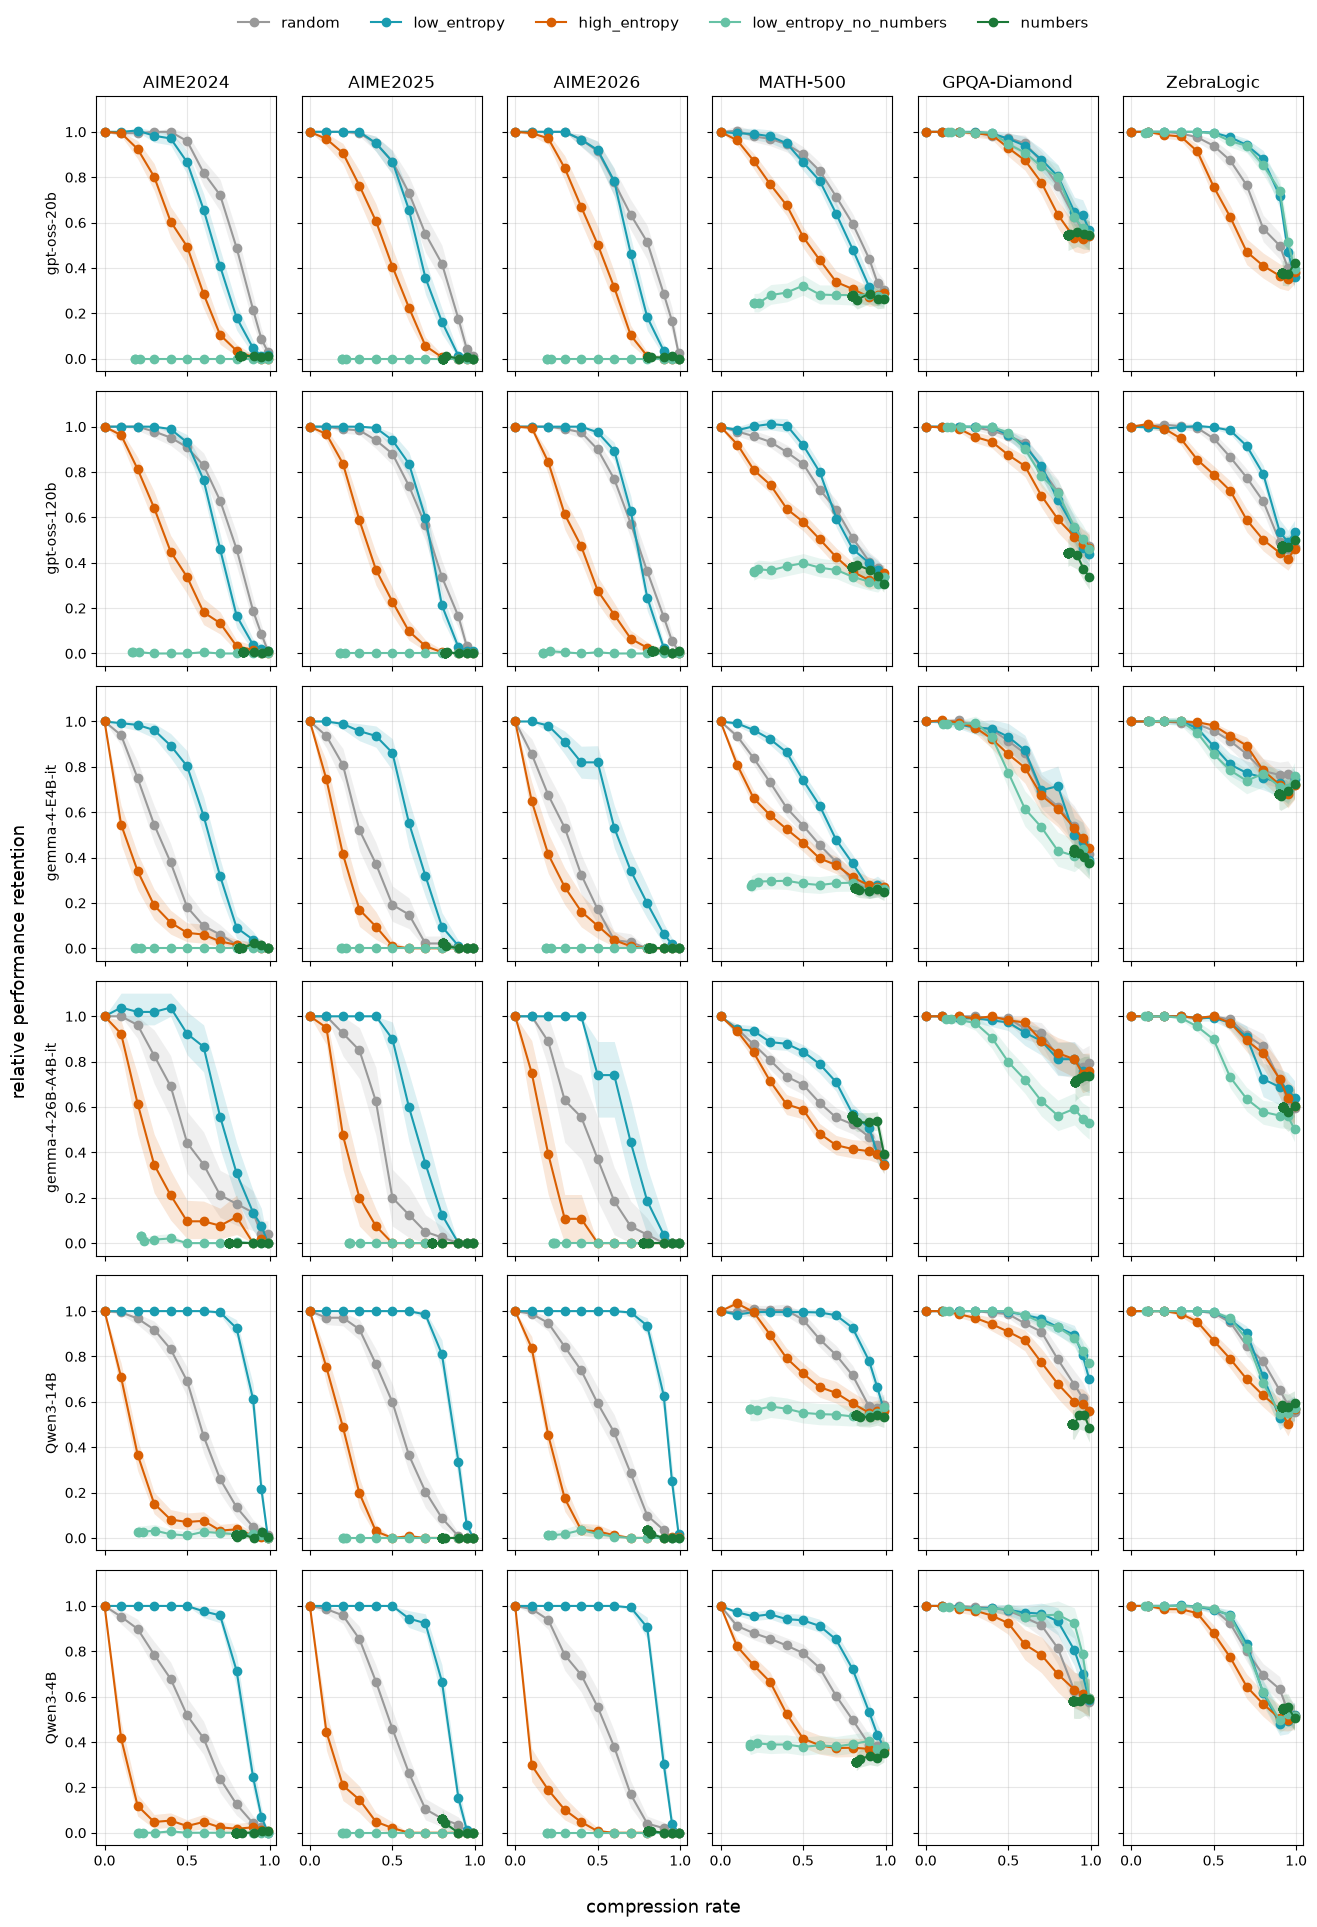

In [30]:
MODELS_TOKEN_GRID = ["gpt-oss-20b", "gpt-oss-120b", "gemma-4-E4B-it", "gemma-4-26B-A4B-it", "Qwen3-14B", "Qwen3-4B"]

TOKEN_SELECTORS_TO_PLOT = ["random", "low_entropy", "high_entropy", "low_entropy_no_numbers", "numbers"]

plot_full_grid(
    models=MODELS_TOKEN_GRID,
    datasets=DATASETS,
    selectors=TOKEN_SELECTORS_TO_PLOT,
    level="token",
    patch=False,
    save="figures/appendix_full_grid_token.pdf",
)


In [31]:
def plot_lowent_no_numbers_ablation_figure(
    model="gpt-oss-120b",
    datasets=("math-500", "gpqa"),
    selectors=("random", "low_entropy", "numbers", "low_entropy_no_numbers"),
    level="token",
    patch=False,
    save=None,
):
    """Two side-by-side panels, normal figure size, each panel narrow
    (taller than wide) rather than square. No title, compact legend,
    minimal top whitespace."""
    n = len(datasets)
    fig, axes = plt.subplots(
        1, n,
        figsize=(2.3 * n, 3.2),
        sharey=True,
    )
    axes = np.atleast_1d(axes)

    for ax, dataset in zip(axes, datasets):
        plot_curves(
            dataset=dataset, model=model, selectors=list(selectors),
            level=level, patch=patch, ax=ax,
            title=DATASET_LABELS.get(dataset, dataset),
        )
        ax.get_legend().remove()
        ax.set_ylabel("")
        ax.set_xlabel("")

    axes[0].set_ylabel("relative performance retention")
    fig.text(0.5, 0.02, "compression rate", ha="center")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc="upper center", ncol=4,
        bbox_to_anchor=(0.5, 0.99), fontsize=8, frameon=False,
        handletextpad=0.3, columnspacing=0.8,
    )
    fig.tight_layout(rect=[0, 0.03, 1, 0.94])

    if save:
        Path(save).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save, dpi=600, bbox_inches="tight")
    plt.show()

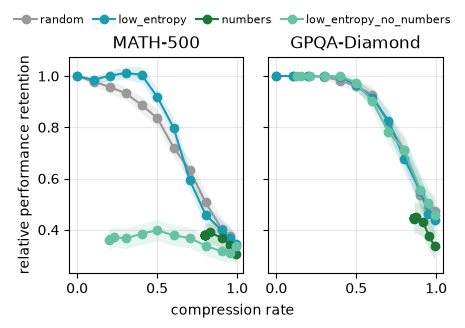

In [51]:
plot_lowent_no_numbers_ablation_figure(
    model="gpt-oss-120b",
    datasets=("math-500", "gpqa"),
    patch=False,
    save="figures/low_entropy_nopatch_gptoss120b.pdf",
)

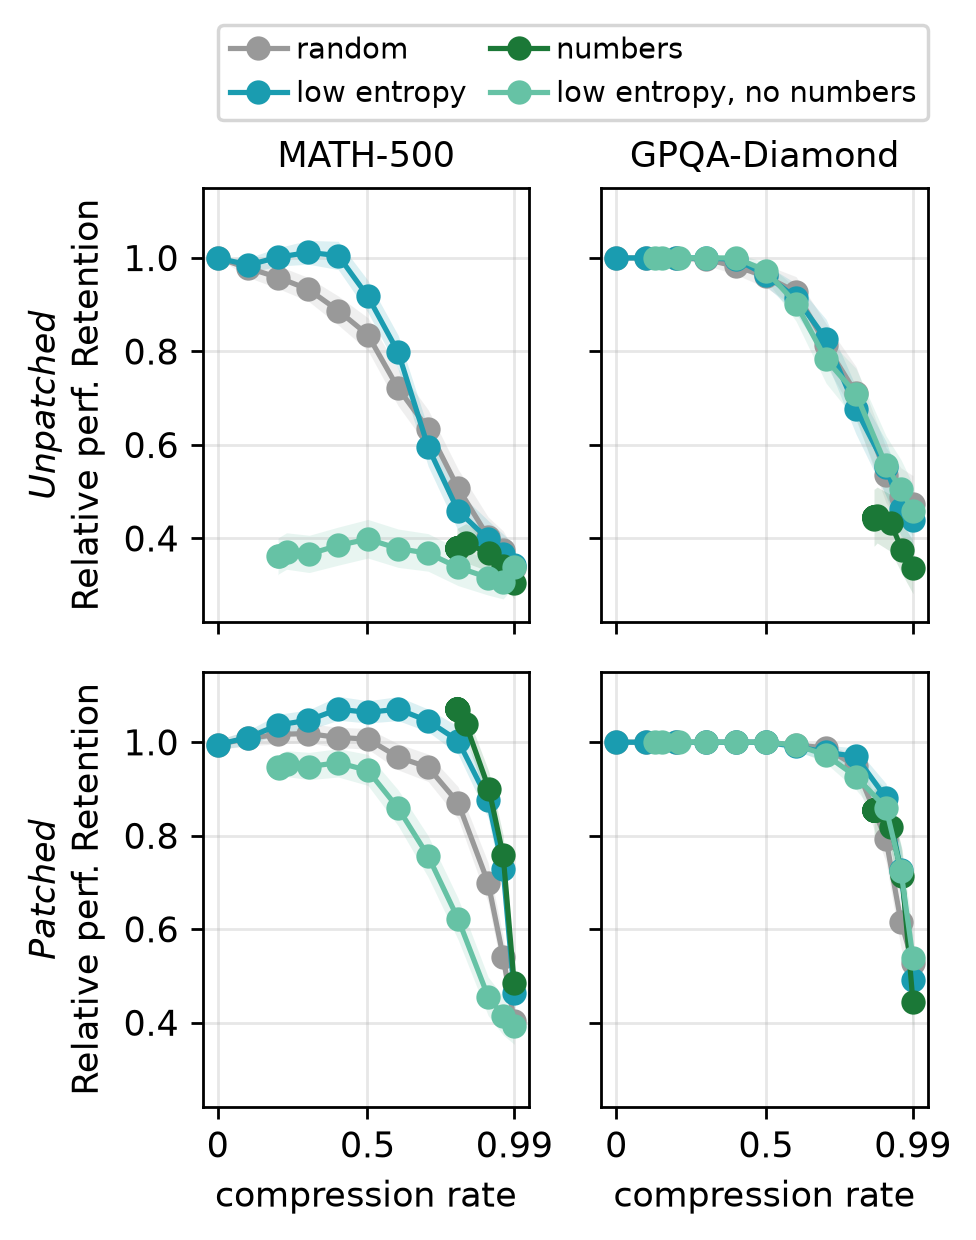

In [117]:
fig, axes = plt.subplots(2, 2, figsize=(4, 4.6), sharex=True, sharey="row", dpi=250)

model = "gpt-oss-120b"
datasets = ("math-500", "gpqa")
patch_values = (False, True)
selectors = ("random", "low_entropy","numbers", "low_entropy_no_numbers")

colors = {"random": "#999999", "low_entropy": "#1A9CB0", "numbers": "#1B7837", "low_entropy_no_numbers": "#66C2A5"}

labels = {"random": "random", "low_entropy": "low entropy", "numbers": "numbers", "low_entropy_no_numbers": "low entropy, no numbers"}

for row, patch in enumerate(patch_values):
    for col, dataset in enumerate(datasets):
        ax = axes[row, col]

        for selector in selectors:
            x, y, ci_low, ci_high = get_curve_with_ci(dataset=dataset, model=model, selector=selector, level="token", patch=patch)
            if len(x) == 0:
                continue
            x = 1 - x  # retention → compression
            color = colors[selector]

            ax.plot(x, y, color=color, marker="o", label=labels[selector])
            ax.fill_between(x, ci_low, ci_high, color=color, alpha=0.15, linewidth=0)
        if row == 0:
            ax.set_title(DATASET_LABELS.get(dataset, dataset), fontsize=10)

        if col == 0:
            condition = "Patched" if patch else "Unpatched"
            ax.set_ylabel(
                rf"$\it{{{condition}}}$" + "\nRelative perf. Retention"
            )
        if row == 1:
            ax.set_xlabel("compression rate")
        ax.grid(alpha=0.3)
        # ax.set_ylim(0.22, 1.1)
        ticks = [0, 0.5, 0.99]
        ax.set_xticks(ticks)
        ax.set_xticklabels([
            f"{tick:g}" if not np.isclose(tick, 0.99) else "0.99"
            for tick in ticks
        ])
        ax.set_ylim(0.22, 1.15)

handles, legend_labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, legend_labels, loc="upper right", ncol=2, 
    bbox_to_anchor=(0.955, 1.08), fontsize='small', handletextpad=0.3, columnspacing=0.8,
)

fig.tight_layout()
fig.savefig(
    "figures/2x2_lowent_grid.pdf",
    bbox_inches="tight",
)
plt.show()

In [35]:
import pandas as pd
import numpy as np

MODELS_ALL = ["Qwen3-4B", "Qwen3-14B", "gemma-4-E4B-it", "gemma-4-26B-A4B-it", "gpt-oss-20b", "gpt-oss-120b"]
DATASETS_ALL = ["aime_2024", "aime2025", "aime_2026", "math-500", "gpqa", "zebralogic"]  # nomi corretti, verificati prima
SELECTORS_ALL = ["low_entropy", "low_entropy_no_numbers", "numbers", "high_entropy"]

rows = []
missing = []

for model in MODELS_ALL:
    for dataset in DATASETS_ALL:
        base = raw_token[
            (raw_token.model == model) &
            (raw_token.dataset == dataset) &
            (raw_token.patched == False)
        ]
        if base.empty:
            missing.append((model, dataset, "NO DATA AT ALL (unpatched)"))
            continue

        row = {"model": model, "dataset": dataset}
        for rng_name, (lo, hi) in [("full", (0.01, 1.0)), ("agg", (0.01, 0.3))]:
            rand_sub = base[base.selector == "random"]
            if rand_sub.empty:
                missing.append((model, dataset, f"missing random ({rng_name})"))
                continue
            rand_auc = auc_in_range_normalized(rand_sub, lo, hi)
            row[f"ranplot_lowent_no_numbers_ablation_figure_gridd_{rng_name}"] = rand_auc

            for sel in SELECTORS_ALL:
                sel_sub = base[base.selector == sel]
                if sel_sub.empty:
                    missing.append((model, dataset, f"missing {sel} ({rng_name})"))
                    continue
                sel_auc = auc_in_range_normalized(sel_sub, lo, hi)
                row[f"delta_{sel}_{rng_name}"] = sel_auc - rand_auc

        rows.append(row)

df_token = pd.DataFrame(rows)

print(f"=== Righe attese: {len(MODELS_ALL) * len(DATASETS_ALL)}, righe ottenute: {len(df_token)} ===\n")

if missing:
    print("--- BUCHI TROVATI (token-level, unpatched) ---")
    for m, d, reason in missing:
        print(f"  {m} / {d}: {reason}")
else:
    print("Nessun buco: tutti i (model, dataset, selector) unpatched hanno dati.")

df_token

=== Righe attese: 36, righe ottenute: 36 ===

--- BUCHI TROVATI (token-level, unpatched) ---
  gemma-4-26B-A4B-it / math-500: missing low_entropy_no_numbers (full)
  gemma-4-26B-A4B-it / math-500: missing low_entropy_no_numbers (agg)
  gpt-oss-120b / zebralogic: missing low_entropy_no_numbers (full)
  gpt-oss-120b / zebralogic: missing low_entropy_no_numbers (agg)


,model,dataset,ranplot_lowent_no_numbers_ablation_figure_gridd_full,delta_low_entropy_full,delta_low_entropy_no_numbers_full,delta_numbers_full,delta_high_entropy_full,ranplot_lowent_no_numbers_ablation_figure_gridd_agg,delta_low_entropy_agg,delta_low_entropy_no_numbers_agg,delta_numbers_agg,delta_high_entropy_agg
0,Qwen3-4B,aime_2024,0.520713,0.324134,-0.520112,-0.520322,-0.391384,0.098625,0.387110,-0.098625,-0.097291,-0.079947
1,Qwen3-4B,aime2025,0.493266,0.330527,-0.493266,-0.441709,-0.355079,0.049569,0.381226,-0.049569,-0.024425,-0.049569
2,Qwen3-4B,aime_2026,0.511364,0.361862,-0.511364,-0.505562,-0.396021,0.048346,0.520037,-0.048346,-0.044851,-0.048346
3,Qwen3-4B,math-500,0.720586,0.130273,-0.333280,-0.404858,-0.183819,0.461693,0.165159,-0.072912,-0.132407,-0.091155
4,Qwen3-4B,gpqa,0.909519,0.036103,0.049093,-0.328582,-0.048130,0.734950,0.110096,0.163939,-0.149404,-0.059833
5,Qwen3-4B,zebralogic,0.880785,-0.014211,-0.013386,-0.336228,-0.071662,0.660211,-0.067286,-0.061012,-0.115305,-0.110266
6,Qwen3-14B,aime_2024,0.585804,0.320693,-0.564701,-0.575184,-0.380262,0.108854,0.572880,-0.093663,-0.097763,-0.086580
7,Qwen3-14B,aime2025,0.544312,0.321721,-0.544312,-0.544312,-0.344872,0.067329,0.477850,-0.067329,-0.067329,-0.067329
8,Qwen3-14B,aime_2026,0.554205,0.356619,-0.543634,-0.526016,-0.347692,0.092622,0.603949,-0.092622,-0.080593,-0.091319
9,Qwen3-14B,math-500,0.877027,0.069178,-0.320033,-0.336965,-0.107208,0.665716,0.166781,-0.121583,-0.129585,-0.082292


# with patching

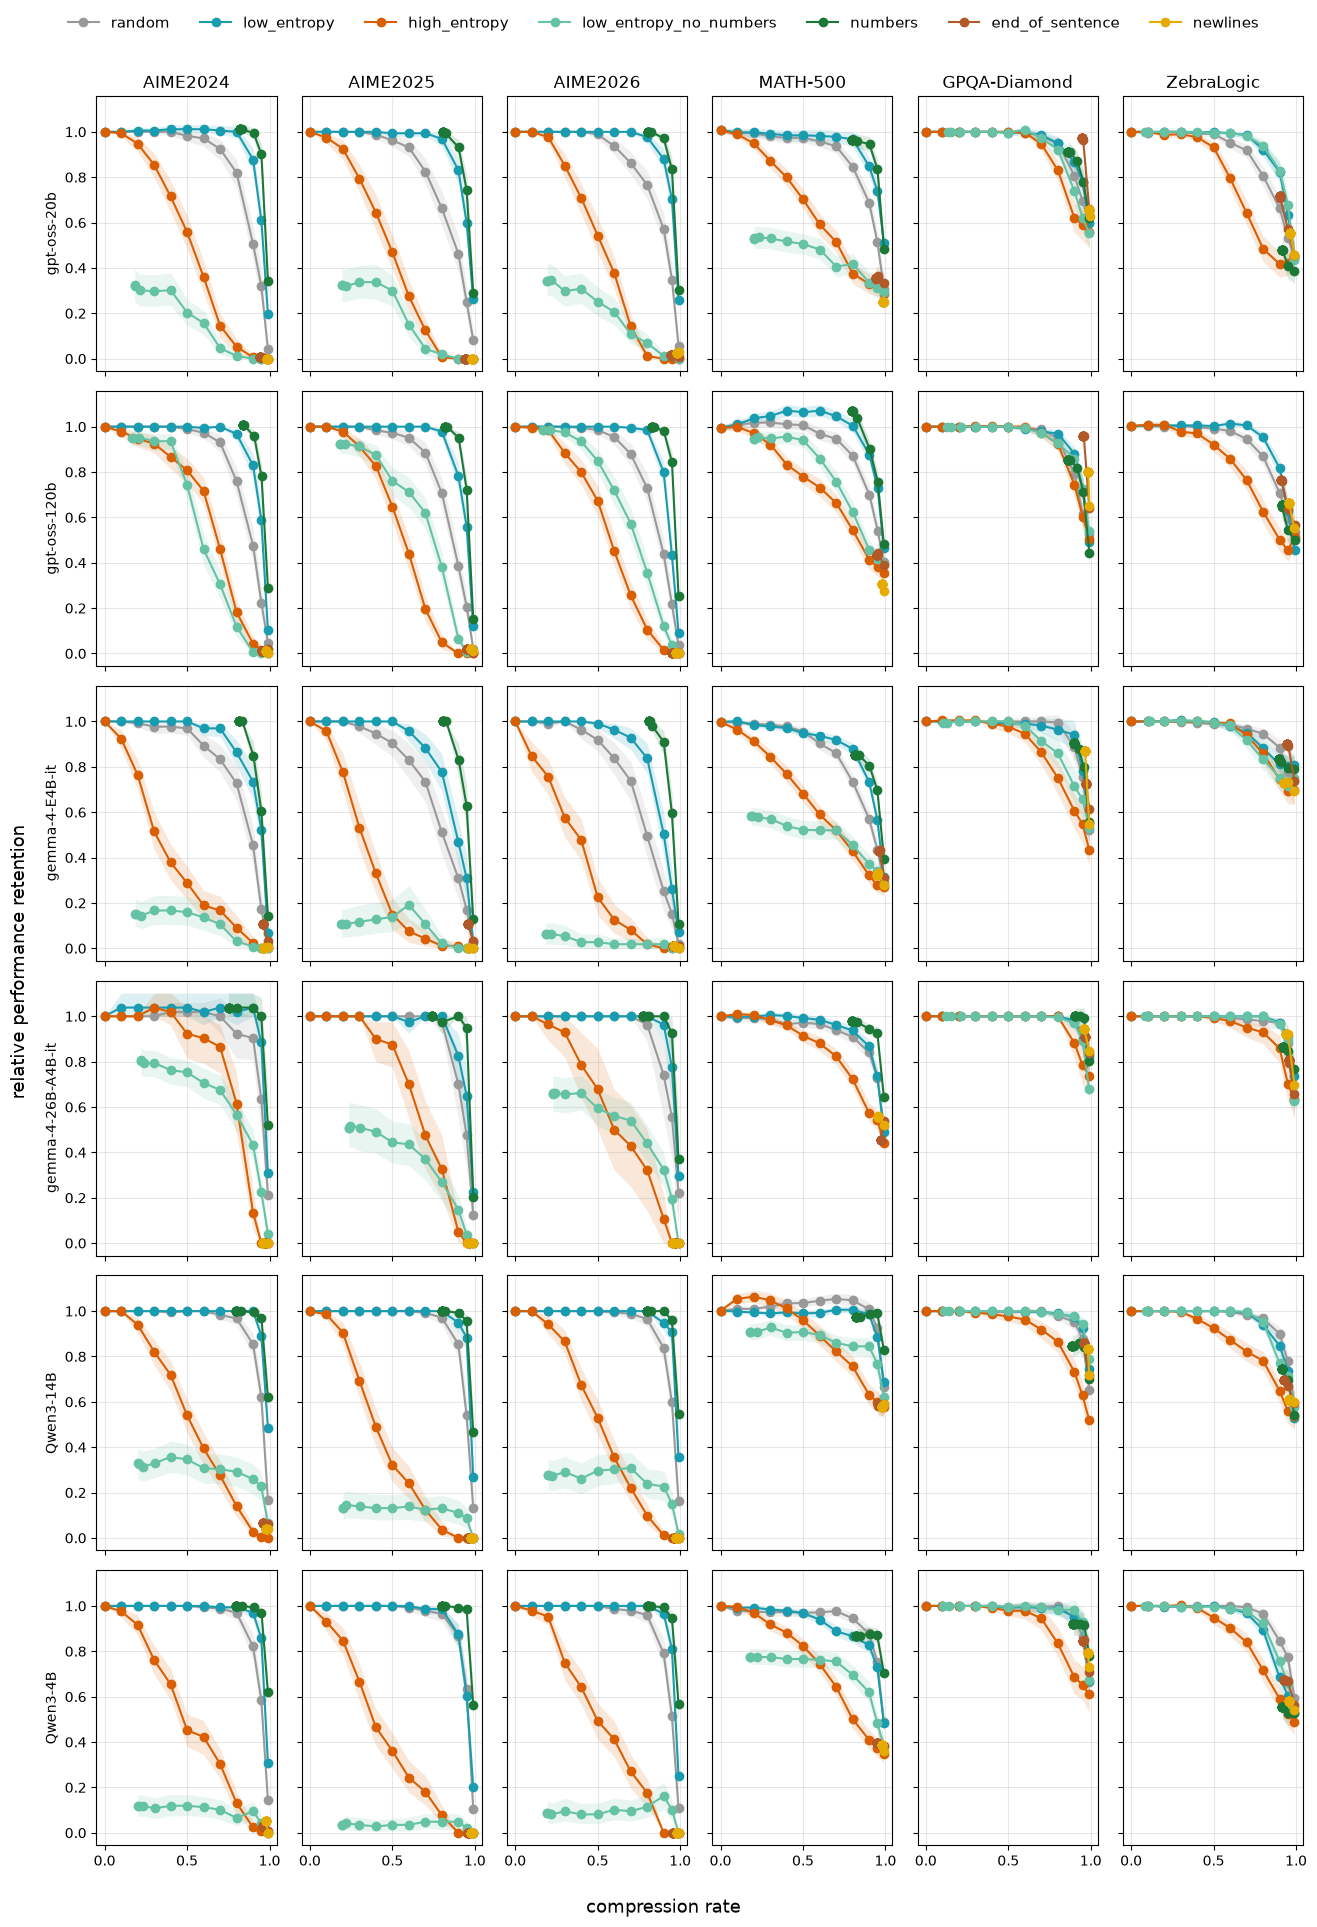

In [36]:
TOKEN_SELECTORS_TO_PLOT = ["random", "low_entropy", "high_entropy", "low_entropy_no_numbers", "numbers", "end_of_sentence", "newlines"]

plot_full_grid(
    models=MODELS_TOKEN_GRID,
    datasets=DATASETS,
    selectors=TOKEN_SELECTORS_TO_PLOT,
    level="token",
    patch=True,
    save="figures/appendix_full_grid_token_patch.pdf",
)


In [37]:
import pandas as pd
import numpy as np

MODELS_ALL = ["Qwen3-4B", "Qwen3-14B", "gemma-4-E4B-it", "gemma-4-26B-A4B-it", "gpt-oss-20b", "gpt-oss-120b"]
DATASETS_ALL = ["aime_2024", "aime2025", "aime_2026", "math-500", "gpqa", "zebralogic"]
SELECTORS_ALL = ["low_entropy", "low_entropy_no_numbers", "numbers", "high_entropy", "newlines", "end_of_sentence"]

rows = []
missing = []

for model in MODELS_ALL:
    for dataset in DATASETS_ALL:
        base = raw_token[
            (raw_token.model == model) &
            (raw_token.dataset == dataset) &
            (raw_token.patched == True)
        ]
        if base.empty:
            missing.append((model, dataset, "NO DATA AT ALL (patched)"))
            continue

        row = {"model": model, "dataset": dataset}
        for rng_name, (lo, hi) in [("full", (0.01, 1.0)), ("agg", (0.01, 0.3))]:
            rand_sub = base[base.selector == "random"]
            if rand_sub.empty:
                missing.append((model, dataset, f"missing random ({rng_name})"))
                continue
            rand_auc = auc_in_range_normalized(rand_sub, lo, hi)
            row[f"rand_{rng_name}"] = rand_auc

            for sel in SELECTORS_ALL:
                sel_sub = base[base.selector == sel]
                if sel_sub.empty:
                    missing.append((model, dataset, f"missing {sel} ({rng_name})"))
                    continue
                sel_auc = auc_in_range_normalized(sel_sub, lo, hi)
                row[f"delta_{sel}_{rng_name}"] = sel_auc - rand_auc

        rows.append(row)

df_token_patched = pd.DataFrame(rows)

print(f"=== Righe attese: {len(MODELS_ALL) * len(DATASETS_ALL)}, righe ottenute: {len(df_token_patched)} ===\n")
if missing:
    print("--- BUCHI TROVATI (token-level, patched) ---")
    for m, d, reason in missing:
        print(f"  {m} / {d}: {reason}")
else:
    print("Nessun buco: tutti i (model, dataset, selector) patched hanno dati.")

df_token_patched

=== Righe attese: 36, righe ottenute: 36 ===

--- BUCHI TROVATI (token-level, patched) ---
  gemma-4-26B-A4B-it / math-500: missing low_entropy_no_numbers (full)
  gemma-4-26B-A4B-it / math-500: missing low_entropy_no_numbers (agg)
  gpt-oss-120b / zebralogic: missing low_entropy_no_numbers (full)
  gpt-oss-120b / zebralogic: missing low_entropy_no_numbers (agg)


,model,dataset,rand_full,delta_low_entropy_full,delta_low_entropy_no_numbers_full,delta_numbers_full,delta_high_entropy_full,delta_newlines_full,delta_end_of_sentence_full,rand_agg,delta_low_entropy_agg,delta_low_entropy_no_numbers_agg,delta_numbers_agg,delta_high_entropy_agg,delta_newlines_agg,delta_end_of_sentence_agg
0,Qwen3-4B,aime_2024,0.945406,0.030694,-0.843104,0.045094,-0.426257,-0.892917,-0.916126,0.817734,0.101704,-0.746613,0.149836,-0.713157,-0.767857,-0.789614
1,Qwen3-4B,aime2025,0.948864,0.004735,-0.911616,0.041141,-0.517466,-0.948864,-0.948864,0.831418,0.012572,-0.790469,0.134459,-0.773946,-0.831418,-0.831418
2,Qwen3-4B,aime_2026,0.936493,0.037196,-0.840773,0.051802,-0.413698,-0.936493,-0.936493,0.791356,0.118826,-0.677773,0.168686,-0.684180,-0.791356,-0.791356
3,Qwen3-4B,math-500,0.945414,-0.020389,-0.216176,-0.080017,-0.185188,-0.558623,-0.549607,0.872238,-0.059890,-0.239862,-0.013022,-0.400589,-0.486735,-0.477204
4,Qwen3-4B,gpqa,0.981938,0.000770,0.004344,-0.065819,-0.056754,-0.190849,-0.137113,0.941993,0.004822,0.013369,-0.033189,-0.170368,-0.154004,-0.103521
5,Qwen3-4B,zebralogic,0.965717,-0.033038,-0.020911,-0.414344,-0.089361,-0.385126,-0.294695,0.883954,-0.101423,-0.061506,-0.336528,-0.225027,-0.305948,-0.218555
6,Qwen3-14B,aime_2024,0.949468,0.035244,-0.641633,0.041005,-0.408545,-0.911630,-0.884712,0.832153,0.115657,-0.572507,0.135322,-0.728332,-0.794315,-0.767661
7,Qwen3-14B,aime2025,0.946804,0.029271,-0.819509,0.039888,-0.512903,-0.946804,-0.946804,0.819658,0.098666,-0.711050,0.134911,-0.785678,-0.819658,-0.819658
8,Qwen3-14B,aime_2026,0.947234,0.031536,-0.681466,0.041755,-0.422510,-0.947234,-0.947234,0.823877,0.103649,-0.605253,0.138532,-0.748697,-0.823877,-0.823877
9,Qwen3-14B,math-500,1.016510,-0.031963,-0.136434,-0.045072,-0.110538,-0.438488,-0.425460,0.993165,-0.032869,-0.172792,-0.023355,-0.294237,-0.414343,-0.403524


In [38]:
TOKEN_SELECTOR_COLS = ["low_entropy", "high_entropy", "numbers", "end_of_sentence", "newlines", "low_entropy_no_numbers"]
DATASETS = ["aime2024", "aime2025", "aime2026", "math500", "gpqa", "zebralogic"]
PATCH_CONDITIONS = [False, True]

token_results = []
for model in sorted(raw_token.model.unique()):
    for dataset in DATASETS:
        for patched in PATCH_CONDITIONS:
            for sel in TOKEN_SELECTOR_COLS:
                res = bootstrap_delta_auc(raw_token, model, dataset, sel, patched=patched)
                if res is None:
                    continue
                point, lo, hi = res
                token_results.append({
                    "model": model, "dataset": dataset, "patched": patched,
                    "selector": sel, "delta_auc": point, "ci_lo": lo, "ci_hi": hi,
                })

token_delta_ci = pd.DataFrame(token_results)

In [39]:
def plot_model_strip(dataset, models, selectors=["random", "low_entropy", "high_entropy"],
                      level="token", patch=False, ncols=None, save=None):
    ncols = ncols or len(models)
    nrows = int(np.ceil(len(models) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.5 * ncols, 4 * nrows), sharey=True)
    axes = np.atleast_1d(axes).flatten()

    for ax, model in zip(axes, models):
        plot_curves(
            dataset=dataset, model=model, selectors=selectors,
            level=level, patch=patch, ax=ax,
            title=model,
        )
        ax.get_legend().remove()
        ax.set_ylabel("")

    for ax in axes[len(models):]:
        ax.axis("off")

    fig.text(0.0, 0.5, "relative performance retention", va="center", rotation="vertical")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(selectors),
               bbox_to_anchor=(0.5, 1.06))
    fig.suptitle(f"{dataset} ({level}{', patch' if patch else ''})", y=1.14)
    fig.tight_layout()

    if save:
        Path(save).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save, dpi=600, bbox_inches="tight")
    plt.show()

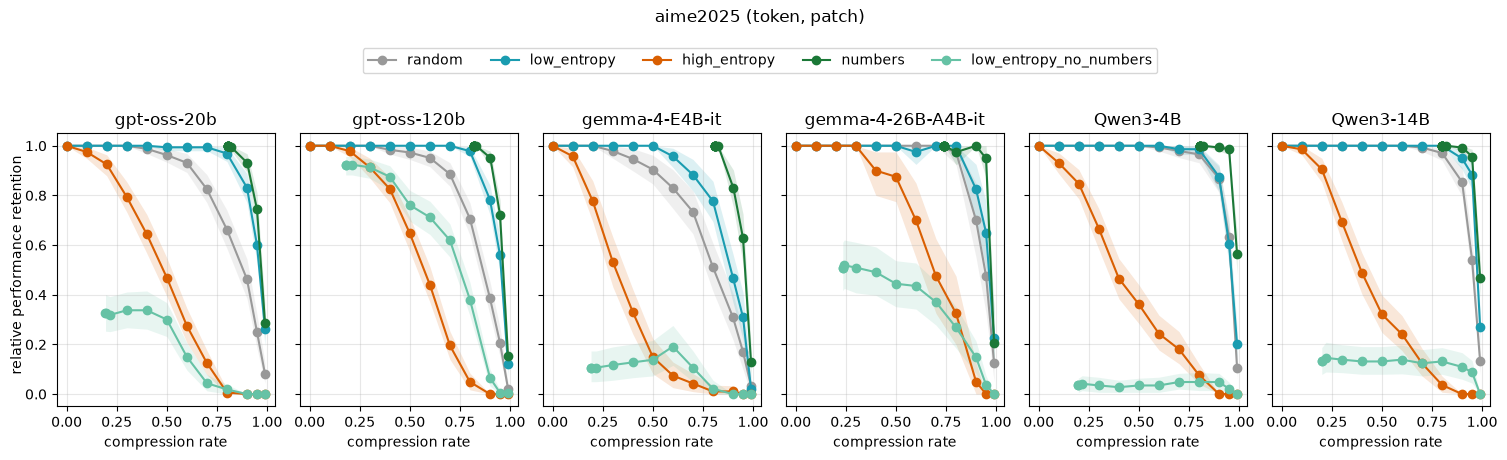

In [40]:
plot_model_strip(
    dataset="aime2025",
    models=["gpt-oss-20b", "gpt-oss-120b", "gemma-4-E4B-it", "gemma-4-26B-A4B-it", "Qwen3-4B", "Qwen3-14B"],
    selectors=["random", "low_entropy", "high_entropy", "numbers", "low_entropy_no_numbers"],
    level="token", patch=True,
    # save="figs/partial_aime2025_patched_strip.pdf",
)

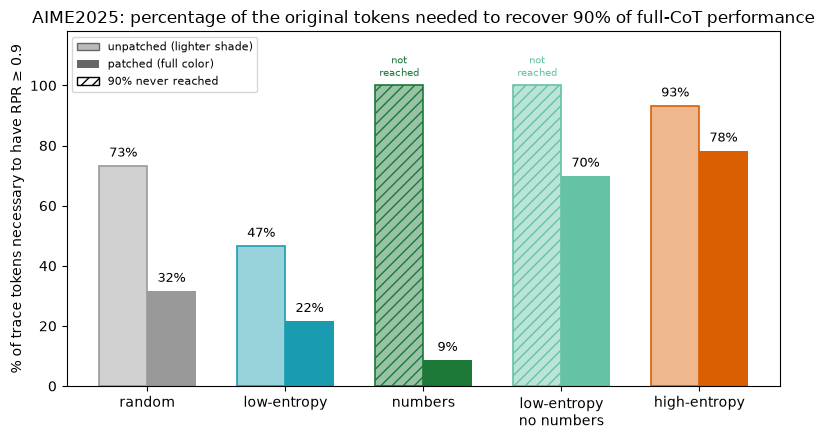

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch

def lighten(color, amount=0.55):
    """Schiarisce un colore mescolandolo con il bianco (amount=0 -> originale, 1 -> bianco)."""
    r, g, b = to_rgb(color)
    return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount)

def min_retention_for_threshold(dataset, model, selector, level="token", patch=False, threshold=0.9):
    """Retention rate più basso a cui RPR >= threshold viene raggiunto e sostenuto fino a r=1.
    Restituisce None se la soglia non viene mai raggiunta stabilmente nel range testato."""
    xs, ys, los, his = get_curve_with_ci(dataset, model, selector, level=level, patch=patch)
    above = ys >= threshold
    if not above.any():
        return None
    for i in range(len(xs)):
        if above[i:].all():
            return xs[i]
    return None

selectors_to_compare = ["random", "low_entropy", "numbers", "low_entropy_no_numbers", "high_entropy"]
selector_display_names = {
    "random": "random",
    "low_entropy": "low-entropy",
    "numbers": "numbers",
    "low_entropy_no_numbers": "low-entropy\nno numbers",
    "high_entropy": "high-entropy",
}

results = {"unpatched": {}, "patched": {}}
for sel in selectors_to_compare:
    unpatched_vals, patched_vals = [], []
    for model in MODELS:
        u = min_retention_for_threshold("aime2025", model, sel, patch=False)
        p = min_retention_for_threshold("aime2025", model, sel, patch=True)
        if u is not None:
            unpatched_vals.append(u)
        if p is not None:
            patched_vals.append(p)
    results["unpatched"][sel] = np.mean(unpatched_vals) if unpatched_vals else None
    results["patched"][sel] = np.mean(patched_vals) if patched_vals else None

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(selectors_to_compare))
width = 0.35
CAP = 100  # altezza (in %) a cui disegnare le barre "not reached"

for i, sel in enumerate(selectors_to_compare):
    base_color = SELECTOR_COLORS.get(sel, "#999999")
    unpatched_color = lighten(base_color, amount=0.55)
    patched_color = base_color

    u_val = results["unpatched"][sel]
    p_val = results["patched"][sel]
    u_pct = u_val * 100 if u_val is not None else None
    p_pct = p_val * 100 if p_val is not None else None

    # --- unpatched ---
    if u_pct is not None:
        ax.bar(i - width/2, u_pct, width, color=unpatched_color, edgecolor=base_color, linewidth=1.2)
        ax.text(i - width/2, u_pct + 2, f"{u_pct:.0f}%", ha="center", va="bottom", fontsize=9)
    else:
        ax.bar(i - width/2, CAP, width, color=unpatched_color, edgecolor=base_color,
               linewidth=1.2, hatch="///")
        ax.text(i - width/2, CAP + 2, "not\nreached", ha="center", va="bottom",
                fontsize=7.5, color=base_color)

    # --- patched ---
    if p_pct is not None:
        ax.bar(i + width/2, p_pct, width, color=patched_color)
        ax.text(i + width/2, p_pct + 2, f"{p_pct:.0f}%", ha="center", va="bottom", fontsize=9)
    else:
        ax.bar(i + width/2, CAP, width, color=patched_color, hatch="///")
        ax.text(i + width/2, CAP + 2, "not\nreached", ha="center", va="bottom",
                fontsize=7.5, color="white")

legend_elems = [
    Patch(facecolor=lighten("#666666", 0.55), edgecolor="#666666", label="unpatched (lighter shade)"),
    Patch(facecolor="#666666", label="patched (full color)"),
    Patch(facecolor="white", edgecolor="black", hatch="///", label="90% never reached"),
]
ax.legend(handles=legend_elems, loc="upper left", fontsize=8, ncol=1)

ax.set_xticks(x)
ax.set_xticklabels([selector_display_names[s] for s in selectors_to_compare], fontsize=10)
ax.set_ylabel("% of trace tokens necessary to have RPR ≥ 0.9")
ax.set_ylim(0, 118)
ax.set_title("AIME2025: percentage of the original tokens needed to recover 90% of full-CoT performance")
plt.tight_layout()
# plt.savefig("figures/appendix_patch_retention_threshold.pdf", dpi=600, bbox_inches="tight")
plt.show()

In [42]:
selector = "numbers"

print(f"=== Curva '{selector}' — AIME2025 ===\n")
for model in MODELS:
    xs, ys, los, his = get_curve_with_ci("aime2025", model, selector, level="token", patch=True)
    print(f"\n-- {model} (patched) --")
    for x, y in zip(xs, ys):
        print(f"  retention={x*100:5.1f}%  RPR={y*100:5.1f}%")

# Trova il retention rate minimo con cui i "numbers" arrivano al 9% circa dei token
# e stampa l'accuracy/RPR corrispondente
target_retention = 0.09
for model in MODELS:
    xs, ys, los, his = get_curve_with_ci("aime2025", model, selector, level="token", patch=True)
    idx = np.argmin(np.abs(xs - target_retention))
    print(f"{model}: retention={xs[idx]*100:.1f}% -> RPR={ys[idx]*100:.1f}% "
          f"(CI: {los[idx]*100:.1f}-{his[idx]*100:.1f}%)")

=== Curva 'numbers' — AIME2025 ===


-- Qwen3-4B (patched) --
  retention=  1.0%  RPR= 56.2%
  retention=  5.0%  RPR= 98.6%
  retention= 10.0%  RPR= 99.3%
  retention= 18.1%  RPR=100.0%
  retention= 19.7%  RPR=100.0%
  retention= 19.7%  RPR=100.0%
  retention= 19.7%  RPR=100.0%
  retention= 19.7%  RPR=100.0%
  retention= 19.7%  RPR=100.0%
  retention= 19.7%  RPR=100.0%
  retention= 19.7%  RPR=100.0%
  retention= 19.7%  RPR=100.0%

-- Qwen3-14B (patched) --
  retention=  1.0%  RPR= 46.7%
  retention=  5.0%  RPR= 95.6%
  retention=  9.8%  RPR= 99.3%
  retention= 18.0%  RPR=100.0%
  retention= 19.9%  RPR=100.0%
  retention= 20.0%  RPR=100.0%
  retention= 20.0%  RPR=100.0%
  retention= 20.0%  RPR=100.0%
  retention= 20.0%  RPR=100.0%
  retention= 20.0%  RPR=100.0%
  retention= 20.0%  RPR=100.0%
  retention= 20.0%  RPR=100.0%

-- gemma-4-E4B-it (patched) --
  retention=  1.0%  RPR= 12.8%
  retention=  5.0%  RPR= 62.8%
  retention=  9.8%  RPR= 83.0%
  retention= 17.4%  RPR=100.0%
  retention

In [43]:
import numpy as np
import pandas as pd
from pathlib import Path

# --- Scopri i dataset realmente presenti su disco, invece di fidarsi della lista DATASETS ---
discovered_datasets = sorted([d.name for d in ROOT.iterdir() if d.is_dir()])
print("Dataset trovati su disco in ROOT:", discovered_datasets)
print("Dataset attesi in DATASETS:      ", DATASETS)
print("Eventuali mismatch:", set(DATASETS) - set(discovered_datasets), "(in DATASETS ma non su disco)")
print()

def min_retention_for_threshold(dataset, model, selector, level="token", patch=False, threshold=0.95):
    """Retention rate più basso a cui RPR >= threshold viene raggiunto e sostenuto fino a r=1.
    Restituisce None se la soglia non viene mai raggiunta stabilmente nel range testato."""
    xs, ys, los, his = get_curve_with_ci(dataset, model, selector, level=level, patch=patch)
    if len(xs) == 0:
        return None
    above = ys >= threshold
    if not above.any():
        return None
    for i in range(len(xs)):
        if above[i:].all():
            return xs[i]
    return None

THRESHOLD = 0.95
selectors_to_check = ["low_entropy", "numbers", "low_entropy_no_numbers", "high_entropy", "random"]

# --- Usa i dataset scoperti su disco, non la lista DATASETS potenzialmente disallineata ---
rows = []
for dataset in discovered_datasets:
    for model in MODELS:
        for sel in selectors_to_check:
            r_patch = min_retention_for_threshold(dataset, model, sel, level="token", patch=True, threshold=THRESHOLD)
            r_nopatch = min_retention_for_threshold(dataset, model, sel, level="token", patch=False, threshold=THRESHOLD)
            rows.append({
                "dataset": DATASET_LABELS.get(dataset, dataset),
                "model": model,
                "selector": sel,
                "min_retention_patched": r_patch,
                "min_retention_unpatched": r_nopatch,
            })

df = pd.DataFrame(rows)

n_expected = len(discovered_datasets) * len(MODELS)

# --- Riepilogo per selettore, aggregato su tutti i modelli e dataset ---
summary = df.groupby("selector").agg(
    n_total=("min_retention_patched", "size"),
    n_reached_patched=("min_retention_patched", lambda x: x.notna().sum()),
    mean_retention_patched=("min_retention_patched", "mean"),
    min_retention_patched=("min_retention_patched", "min"),
    max_retention_patched=("min_retention_patched", "max"),
    n_reached_unpatched=("min_retention_unpatched", lambda x: x.notna().sum()),
    mean_retention_unpatched=("min_retention_unpatched", "mean"),
).reset_index()

summary["pct_reached_patched"] = 100 * summary["n_reached_patched"] / summary["n_total"]
summary["pct_reached_unpatched"] = 100 * summary["n_reached_unpatched"] / summary["n_total"]

print(f"Near-perfect recovery = RPR >= {THRESHOLD}, sustained to r=1")
print(f"Expected combos per selector: {n_expected} ({len(discovered_datasets)} datasets x {len(MODELS)} models)\n")
print(summary.to_string(index=False))

# --- Breakdown per (dataset, selector) ---
print("\n\nPer-dataset breakdown (mean min retention needed, patched):\n")
pivot = df[df["selector"].isin(["low_entropy", "numbers"])].pivot_table(
    index="dataset", columns="selector", values="min_retention_patched", aggfunc="mean"
)
print(pivot.to_string())

# --- Conteggio "never reached" per dataset, per capire se è un vero effetto o un dataset non caricato ---
print("\n\nCount of 'never reached' (patched) per dataset x selector "
      "(should be 0/6 or partial if real effect, 6/6 if likely a loading issue):\n")
never_reached_counts = (
    df[df["selector"].isin(["low_entropy", "numbers"])]
    .assign(never_reached=lambda d: d["min_retention_patched"].isna())
    .pivot_table(index="dataset", columns="selector", values="never_reached", aggfunc="sum")
)
print(never_reached_counts.to_string())

Dataset trovati su disco in ROOT: ['.cache', 'aime2025', 'aime_2024', 'aime_2026', 'gpqa', 'math-500', 'non-math-mmlu-pro', 'zebralogic']
Dataset attesi in DATASETS:       ['aime2024', 'aime2025', 'aime2026', 'math500', 'gpqa', 'zebralogic']
Eventuali mismatch: {'aime2026', 'math500', 'aime2024'} (in DATASETS ma non su disco)

Near-perfect recovery = RPR >= 0.95, sustained to r=1
Expected combos per selector: 48 (8 datasets x 6 models)

              selector  n_total  n_reached_patched  mean_retention_patched  min_retention_patched  max_retention_patched  n_reached_unpatched  mean_retention_unpatched  pct_reached_patched  pct_reached_unpatched
          high_entropy       48                 36                0.702469               0.199870               1.000000                   36                  0.838694            75.000000              75.000000
           low_entropy       48                 36                0.221896               0.099771               0.599327               

# numerical overshoot

In [44]:
records_full_split = []
for level in ["token", "sentence"]:
    for dataset in DATASETS:
        for model in MODELS:
            for sel in SELECTOR_COLORS.keys():
                if sel == "random":
                    continue
                patch_values = [False, True] if level == "token" else [False]
                for patch in patch_values:
                    xs, ys, los, his = get_curve_with_ci(dataset, model, sel, level=level, patch=patch)
                    for x, y, lo, hi in zip(xs, ys, los, his):
                        records_full_split.append({
                            "level": level, "selector": sel, "patch": patch,
                            "point": y, "ci_lo": lo,
                            "above_1": y >= 1.0,           # <-- fix: >=
                            "ci_excludes_1_above": lo > 1.0,  # <-- fix: > (significatività stretta)
                        })

all_points_split = pd.DataFrame(records_full_split)
overshoot_split = all_points_split.groupby(["level", "selector", "patch"]).agg(
    n_total=("point", "size"),
    n_above_1=("above_1", "sum"),
    n_significant=("ci_excludes_1_above", "sum"),
    mean_point_above=("point", lambda s: s[s >= 1.0].mean() if (s >= 1.0).any() else np.nan),
)
overshoot_split["pct_above_1"] = (overshoot_split["n_above_1"] / overshoot_split["n_total"] * 100).round(1)
overshoot_split["pct_significant_of_above"] = (
    overshoot_split["n_significant"] / overshoot_split["n_above_1"].replace(0, np.nan) * 100
).round(1)
overshoot_split["mean_point_above"] = overshoot_split["mean_point_above"].round(3)

print(overshoot_split[["n_total", "pct_above_1", "pct_significant_of_above", "mean_point_above"]])

                                       n_total  pct_above_1  \
level    selector               patch                         
sentence high_entropy           False      216         29.2   
         low_entropy            False      216         34.3   
         low_entropy_no_numbers False      216         32.4   
         numbers                False      216         25.9   
token    end_of_sentence        False      216          0.0   
                                True       216          0.0   
         high_entropy           False      216         17.6   
                                True       216         30.1   
         low_entropy            False      216         32.9   
                                True       216         53.2   
         low_entropy_no_numbers False      204         16.7   
                                True       204         32.4   
         newlines               False      216          0.0   
                                True       216         

In [45]:
records_full_split = []
for level in ["token", "sentence"]:
    for dataset in DATASETS:
        for model in MODELS:
            for sel in SELECTOR_COLORS.keys():
                if sel == "random":
                    continue
                patch_values = [False, True] if level == "token" else [False]
                for patch in patch_values:
                    xs, ys, los, his = get_curve_with_ci(dataset, model, sel, level=level, patch=patch)
                    for x, y, lo, hi in zip(xs, ys, los, his):
                        records_full_split.append({
                            "level": level, "selector": sel, "patch": patch,
                            "point": y, "ci_lo": lo,
                            "above_1": y > 1.0,
                            "ci_excludes_1_above": lo > 1.0,
                        })

all_points_split = pd.DataFrame(records_full_split)

overshoot_split = all_points_split.groupby(["level", "selector", "patch"]).agg(
    n_total=("point", "size"),
    n_above_1=("above_1", "sum"),
    n_significant=("ci_excludes_1_above", "sum"),
    mean_point_above=("point", lambda s: s[s > 1.0].mean() if (s > 1.0).any() else np.nan),
)
overshoot_split["pct_above_1"] = (overshoot_split["n_above_1"] / overshoot_split["n_total"] * 100).round(1)
overshoot_split["pct_significant_of_above"] = (overshoot_split["n_significant"] / overshoot_split["n_above_1"] * 100).round(1)
overshoot_split["mean_point_above"] = overshoot_split["mean_point_above"].round(3)

print(overshoot_split[["n_total", "pct_above_1", "pct_significant_of_above", "mean_point_above"]])

                                       n_total  pct_above_1  \
level    selector               patch                         
sentence high_entropy           False      216          0.9   
         low_entropy            False      216          1.4   
         low_entropy_no_numbers False      216          1.4   
         numbers                False      216          1.9   
token    end_of_sentence        False      216          0.0   
                                True       216          0.0   
         high_entropy           False      216          0.9   
                                True       216          4.2   
         low_entropy            False      216          1.4   
                                True       216          4.6   
         low_entropy_no_numbers False      204          1.0   
                                True       204          1.5   
         newlines               False      216          0.0   
                                True       216         

## 10. Appendix: math_verify-based semantic matching (skip_patched=True files only)

The cells below do NOT modify any file on disk. They recompute correctness
in-memory from the already-saved `generated_answer` strings (re-adding
`suffix_text`, since that's what was actually fed to `check_correct` at
generation time and what any \boxed{{}} extraction depends on).

Restricted to `skip_patched=True` files: those never have
`reached_patched`/`random_patched` keys, so every condition present
(`full_sequence`, `reached_only`, `random_only`, `no_cot`) has a saved
`generated_answer` and can be fully re-verified. This is intended as an
appendix-only robustness check, run on both sentence- and token-level
sweeps that used `--skip_patched True`.

In [46]:
import sys as _sys

# Make entropy.core.utils importable regardless of where this notebook's
# cwd happens to be relative to the repo root.
for _candidate in [Path("..").resolve(), Path(".").resolve(), Path("../..").resolve()]:
    if (_candidate / "entropy" / "core" / "utils.py").exists():
        if str(_candidate) not in _sys.path:
            _sys.path.insert(0, str(_candidate))
        break

from entropy.core.utils import check_correct

MCQ_DATASETS = {"gpqa", "zebralogic"}

def answer_domain_for(dataset):
    return "mcq" if dataset in MCQ_DATASETS else "math"


In [47]:
def per_trace_correctness_semantic(data, dataset, patch=False):
    """Semantic-match version of per_trace_correctness. Only meaningful
    for skip_patched=True files (no reached_patched/random_patched keys),
    where every condition has a saved generated_answer we can re-verify.
    Re-adds suffix_text before check_correct, since that's what was
    actually fed to check_correct at generation time (extract_boxed_answer
    needs the opening brace that lives in suffix_text, not in
    generated_answer alone)."""
    key = "reached_patched" if patch else "reached_only"
    domain = answer_domain_for(dataset)
    suffix_text = data.get("suffix_text", "")
    sel, full = [], []
    for item in data["results"]:
        tr = item["trace"]
        gt = str(item["GT_answer"])
        if key not in tr or "full_sequence" not in tr:
            continue

        sel_block = tr[key]
        if "generated_answer" in sel_block:
            sel_correct = check_correct(suffix_text + sel_block["generated_answer"], gt, answer_domain=domain)
        else:
            sel_correct = bool(sel_block["correct"])

        full_gen = tr["full_sequence"].get("generated_answer")
        if full_gen is not None:
            full_correct = check_correct(suffix_text + full_gen, gt, answer_domain=domain)
        else:
            full_correct = bool(tr["full_sequence"]["correct"])

        sel.append(int(sel_correct))
        full.append(int(full_correct))
    return np.array(sel), np.array(full)


def get_curve_with_ci_semantic(dataset, model, selector, level="token", patch=False):
    loader = load_token_json if level == "token" else load_sentence_json
    xs, ys, los, his = [], [], [], []
    for rate in RATES:
        data = loader(dataset, model, selector, rate)
        if data is None:
            continue
        sel, full = per_trace_correctness_semantic(data, dataset, patch=(patch if level == "token" else False))
        point, lo, hi = bootstrap_relative_pr(sel, full)
        if point is None:
            continue

        actual_retentions = []
        for item in data["results"]:
            tr = item["trace"]
            nr = tr.get("n_tokens_reached")
            nt = tr.get("n_tokens_thinking")
            if nr is not None and nt:
                actual_retentions.append(nr / nt)
        actual_retention = np.mean(actual_retentions) if actual_retentions else float(rate)

        xs.append(actual_retention); ys.append(point); los.append(lo); his.append(hi)

    xs = np.array(xs)
    order = np.argsort(xs)
    return xs[order], np.array(ys)[order], np.array(los)[order], np.array(his)[order]


In [48]:
def plot_curves_semantic(dataset, model, selectors, level="token", patch=False,
                          x_axis="compression", title=None, ax=None):
    """Same as plot_curves, but using math_verify-based semantic matching
    instead of the stored (exact-match) correct flags. Appendix use only:
    valid for skip_patched=True files (no patched conditions to fall back on)."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(6, 4))
    for sel in selectors:
        xs, ys, los, his = get_curve_with_ci_semantic(dataset, model, sel, level=level, patch=patch)
        if len(xs) == 0:
            continue
        if x_axis == "compression":
            xs = 1 - xs
        color = SELECTOR_COLORS.get(sel, None)
        ax.plot(xs, ys, marker="o", label=sel, color=color)
        ax.fill_between(xs, los, his, color=color, alpha=0.15, linewidth=0)
    ax.set_xlabel("compression rate" if x_axis == "compression" else "retention rate")
    ax.set_ylabel("relative performance retention")
    ax.set_title(title or f"{model} / {dataset} ({level}, math_verify)")
    ax.legend()
    ax.grid(alpha=0.3)
    if standalone:
        plt.show()


def plot_full_grid_semantic(models, datasets, selectors=("random", "low_entropy", "high_entropy"),
                             level="token", save=None, scale=0.62):
    """scale: fattore di riduzione rispetto alla versione full-page (1.0 = full page).
    Con scale~0.6 due griglie (sentence + token) stanno sulla stessa pagina,
    mantenendo font leggibili perché i fontsize NON vengono scalati insieme al figsize."""
    nrows, ncols = len(models), len(datasets)
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.2 * ncols * scale, 3.2 * nrows * scale),
        sharex=True, sharey=True,
    )
    axes = np.asarray(axes).reshape(nrows, ncols)

    for i, model in enumerate(models):
        for j, dataset in enumerate(datasets):
            ax = axes[i, j]
            plot_curves_semantic(dataset=dataset, model=model, selectors=list(selectors),
                                  level=level, ax=ax)
            ax.set_title("")
            ax.get_legend().remove()
            ax.set_ylabel("")
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelsize=10)
            if i == 0:
                ax.set_title(DATASET_LABELS.get(dataset, dataset), fontsize=11)
            if j == 0:
                ax.set_ylabel(model, fontsize=11)

    fig.tight_layout(rect=[0.03, 0.03, 1, 0.95])

    fig.text(0.005, 0.5, "relative performance retention",
              va="center", rotation="vertical", fontsize=13)
    fig.text(0.5, 0.005, "compression rate",
              ha="center", fontsize=13)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(selectors),
               bbox_to_anchor=(0.5, 1.0), frameon=False, fontsize=11)

    if save:
        Path(save).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save, dpi=600, bbox_inches="tight")
    plt.show()

Timeout during comparison
Timeout during comparison
Timeout during comparison
Timeout during comparison
Timeout during comparison
Timeout during comparison


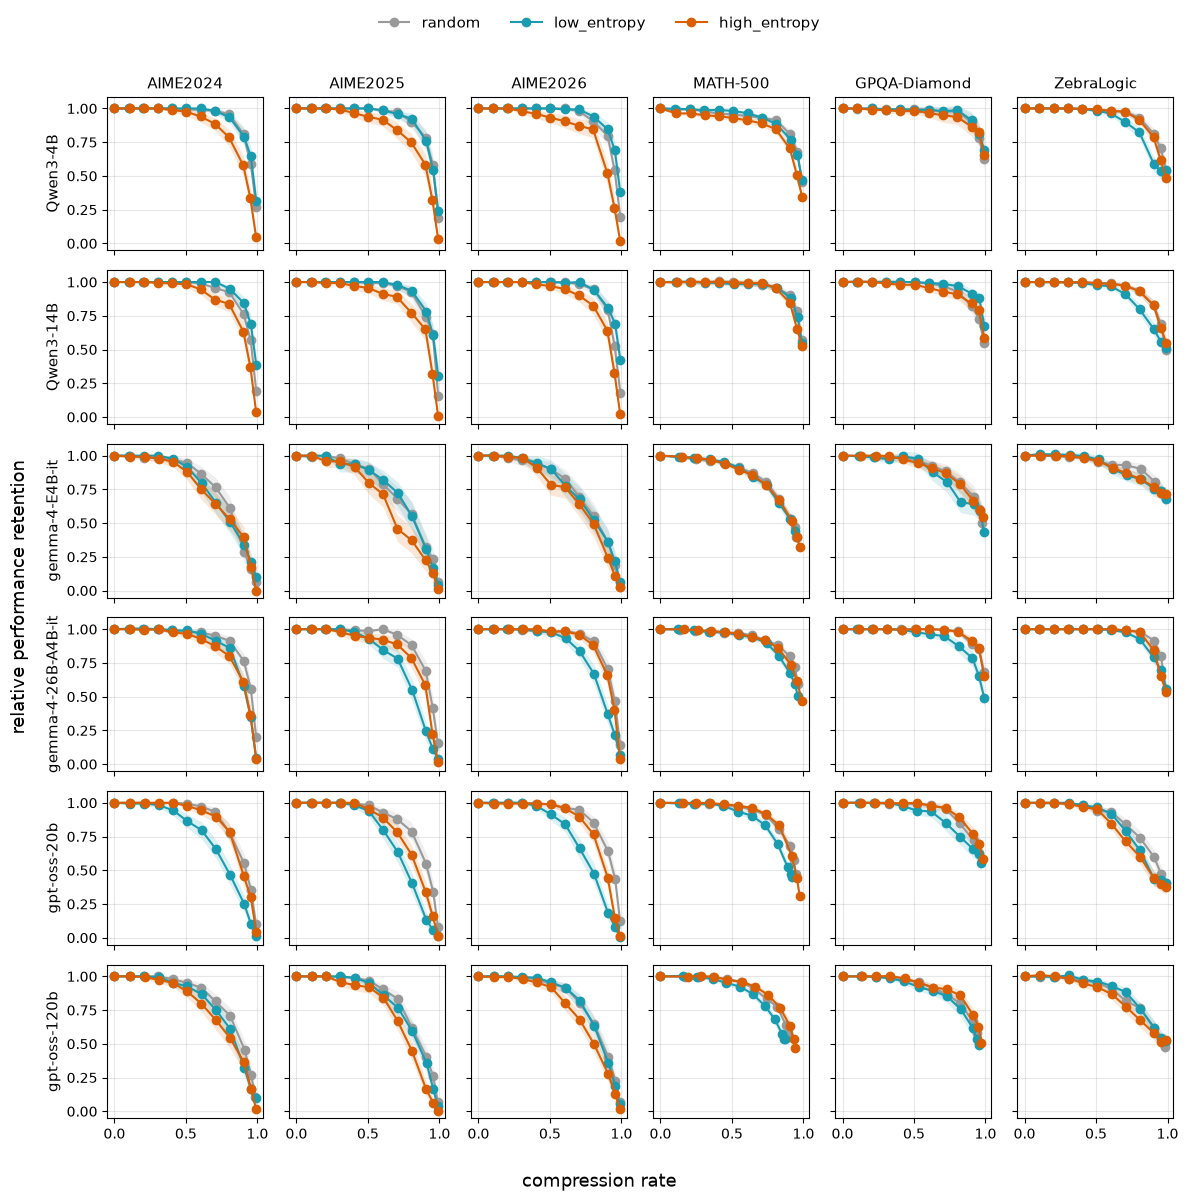

In [49]:
plot_full_grid_semantic(
    models=MODELS,
    datasets=["aime_2024", "aime2025", "aime_2026", "math-500", "gpqa", "zebralogic"],
    selectors=("random", "low_entropy", "high_entropy"),
    level="sentence",
    save="figures/appendix_full_grid_sentence_mathverify.pdf",
)

KeyboardInterrupt: 

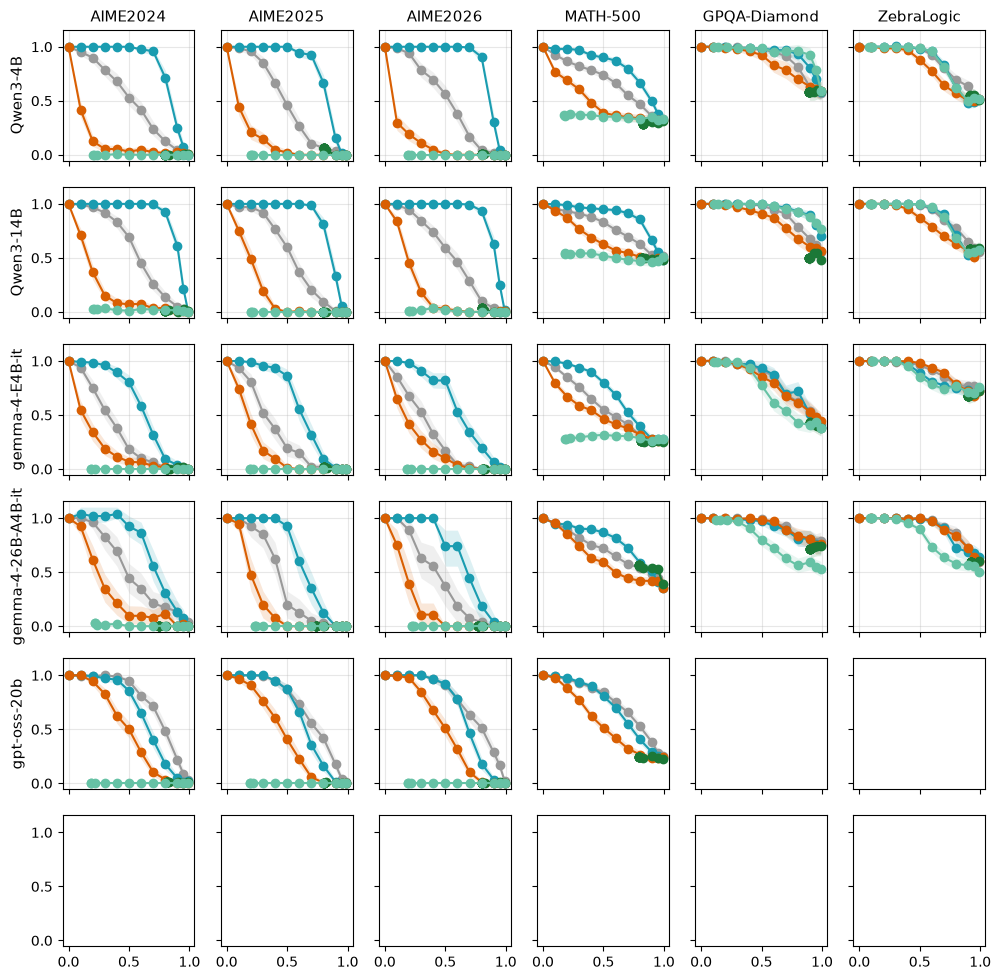

In [50]:
plot_full_grid_semantic(
    models=MODELS,
    datasets=["aime_2024", "aime2025", "aime_2026", "math-500", "gpqa", "zebralogic"],
    selectors=("random", "low_entropy", "high_entropy", "numbers", "low_entropy_no_numbers"),
    level="token",
    save="figures/appendix_full_grid_token_mathverify.pdf",
)

In [ ]:
plot_full_grid_semantic(
    models=["gpt-oss-120b"],
    datasets=["math-500", "gpqa"],
    selectors=("random", "low_entropy", "high_entropy"),
    level="token",
)